# MFCC + Ensemble Model — Noise Robustness Experiments

**Course:** EGN 2203 / ELE 4653 – Final Project | Focus Area 2  
**Dataset:** ESC-50 (50 environmental sound classes)  
**Model:** Subspace Discriminant Ensemble (30 LDA learners, 195 MFCC features)  

---

## Experimental Design

| Condition | Description |
|-----------|-------------|
| **Condition 1** | Clean audio — baseline accuracy |
| **Condition 2** | Noisy audio — no preprocessing |
| **Condition 3** | Noisy audio + MMSE-LSA DSP denoising |

**Noise types and SNR levels tested:**
- White Noise @ SNR = 0, 5, 10, 15 dB
- Gaussian Noise @ SNR = 0, 5, 10, 15 dB
- Low-SNR (Pink) Noise @ SNR = −5, 0, 5 dB

---

> **Reproducibility:** Set `RANDOM_SEED = 45` throughout. All stochastic operations (noise addition, model training) use this seed.

## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Google Drive Mount & Paths](#2-google-drive-mount--paths)
3. [Feature Extraction (CSV Generation)](#3-feature-extraction-csv-generation)
4. [Load Features & Prepare Data](#4-load-features--prepare-data)
5. [Train Ensemble Classifier](#5-train-ensemble-classifier)
6. [Load Raw Audio for Noise Experiments](#6-load-raw-audio-for-noise-experiments)
7. [DSP Analysis: Pre-emphasis + FFT + STFT](#7-dsp-analysis-pre-emphasis--fft--stft)
8. [Noise Addition Functions](#8-noise-addition-functions)
9. [MMSE-LSA Denoising Filter](#9-mmse-lsa-denoising-filter)
10. [Condition 1 — Clean Baseline](#10-condition-1--clean-baseline)
11. [Condition 2 — Noisy Audio](#11-condition-2--noisy-audio)
12. [Condition 3 — Noisy + DSP](#12-condition-3--noisy--dsp)
13. [Results Table](#13-results-table)
14. [Visualizations](#14-visualizations)
15. [Confusion Matrices](#15-confusion-matrices)
16. [Evaluation Metrics & ROC Curves](#16-evaluation-metrics--roc-curves)
17. [Final Summary](#17-final-summary)

---
## 1. Environment Setup

In [31]:
# ============================================================
# CELL 1 — Install dependencies and import all libraries
# ============================================================
# Run once per Colab session. All packages are pinned implicitly
# by Colab's runtime; if you need strict version pinning, add
# e.g. librosa==0.10.1 to the pip command below.
# ============================================================

!pip install librosa scikit-learn pandas numpy matplotlib seaborn scipy tqdm -q

# ── Standard library ──────────────────────────────────────────
import os

# ── Numerical / data ──────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Audio ─────────────────────────────────────────────────────
import librosa
import librosa.display

# ── Plotting ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Signal processing ─────────────────────────────────────────
from scipy.signal   import butter, sosfilt
from scipy.ndimage  import uniform_filter1d
from scipy.special  import exp1

# ── Machine learning ──────────────────────────────────────────
from sklearn.ensemble              import BaggingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing         import StandardScaler, label_binarize
from sklearn.metrics               import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score,
    recall_score, f1_score,
    roc_curve, auc,
)

# ── Progress bar ──────────────────────────────────────────────
from tqdm import tqdm

# ── Global reproducibility seed ───────────────────────────────
RANDOM_SEED = 45
np.random.seed(RANDOM_SEED)

print("All imports ready!")

All imports ready!


---
## 2. Google Drive Mount & Paths

In [32]:
# ============================================================
# CELL 2 — Mount Google Drive and define all project paths
# ============================================================
# Paths are centralised here so that changing the project root
# (DRIVE_BASE) automatically propagates everywhere else.
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# ── Project root ──────────────────────────────────────────────
DRIVE_BASE  = "/content/drive/MyDrive/DSP Project"

# ── Input paths ───────────────────────────────────────────────
TRAIN_CSV   = f"{DRIVE_BASE}/train_mfcc.csv"
TEST_CSV    = f"{DRIVE_BASE}/test_mfcc.csv"
AUDIO_DIR   = f"{DRIVE_BASE}/esc50_data/ESC-50-master/audio"
META_PATH   = f"{DRIVE_BASE}/esc50_data/ESC-50-master/meta/esc50.csv"

# ── Output path ───────────────────────────────────────────────
RESULTS_DIR = f"{DRIVE_BASE}/mfcc_noise_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Verify that required inputs exist ─────────────────────────
required_paths = {
    "Train CSV" : TRAIN_CSV,
    "Test CSV"  : TEST_CSV,
    "Audio dir" : AUDIO_DIR,
    "Meta CSV"  : META_PATH,
}
for label, path in required_paths.items():
    status = "exists" if os.path.exists(path) else "MISSING"
    print(f"{status} {label}: {path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
exists Train CSV: /content/drive/MyDrive/DSP Project/train_mfcc.csv
exists Test CSV: /content/drive/MyDrive/DSP Project/test_mfcc.csv
exists Audio dir: /content/drive/MyDrive/DSP Project/esc50_data/ESC-50-master/audio
exists Meta CSV: /content/drive/MyDrive/DSP Project/esc50_data/ESC-50-master/meta/esc50.csv


---
## 3. Feature Extraction (CSV Generation)

> **Skip this section** if `train_mfcc.csv` and `test_mfcc.csv` already exist on Drive.  
> These cells extract 195-dimensional MFCC feature vectors from the raw ESC-50 audio and save them to CSV for fast reloading in later sessions.

In [33]:
# ============================================================
# CELL 3 — Audio & feature-extraction hyperparameters
# ============================================================
# All constants are defined once here and imported by every
# downstream cell that touches audio or features.
# ============================================================

from pathlib import Path

# ── Audio loading ─────────────────────────────────────────────
SR          = 44_100          # Sample rate (Hz)
CLIP_LEN    = SR * 5          # Fixed clip length: 5 s = 220 500 samples

# ── MFCC / mel-spectrogram parameters ────────────────────────
N_MFCC      = 13
N_FFT       = 2048
HOP_LENGTH  = 1024
N_MELS      = 128
FMIN        = 50              # Low-frequency cutoff (Hz)
FMAX        = 8_000           # High-frequency cutoff (Hz)

# ── Target RMS normalisation level ───────────────────────────
TARGET_RMS  = 0.1

# ── Train / test split (ESC-50 uses predefined folds 1–5) ────
TRAIN_FOLDS = [1, 2, 3, 4]
TEST_FOLD   = 5

# ── Data augmentation ────────────────────────────────────────
N_AUG_COPIES      = 2     # Each training clip → 1 original + 2 augmented copies
SILENCE_THRESHOLD = 0.30  # Discard silence trim when it removes >30 % of signal

print("Configuration loaded.")
print(f"   SR={SR} Hz | clip={CLIP_LEN/SR:.0f}s | "
      f"N_MFCC={N_MFCC} | HOP={HOP_LENGTH} | "
      f"fmin={FMIN}–{FMAX} Hz")

Configuration loaded.
   SR=44100 Hz | clip=5s | N_MFCC=13 | HOP=1024 | fmin=50–8000 Hz


In [34]:
# ============================================================
# CELL 4 — Preprocessing helpers
# ============================================================
# These functions are applied identically to every clip
# (train AND test) before any augmentation or feature
# extraction, ensuring a consistent input distribution.
# ============================================================

def pad_or_trim(y: np.ndarray) -> np.ndarray:
    """Ensure clip is exactly CLIP_LEN samples long."""
    if len(y) > CLIP_LEN:
        return y[:CLIP_LEN]
    return np.pad(y, (0, CLIP_LEN - len(y))).astype(np.float32)


def rms_normalize(y: np.ndarray, target: float = TARGET_RMS) -> np.ndarray:
    """Scale waveform so its RMS equals *target* (default 0.1).

    Clips below a near-zero floor are returned unchanged to
    avoid amplifying digital silence into noise.
    """
    rms = np.sqrt(np.mean(y ** 2))
    if rms < 1e-9:          # silence guard
        return y
    return (y * (target / rms)).astype(np.float32)


def silence_trim(y: np.ndarray, top_db: int = 20) -> np.ndarray:
    """Remove leading/trailing silence.

    Falls back to the original clip when trimming would remove
    ≥ SILENCE_THRESHOLD of the signal (protects short transients).
    """
    y_trimmed, _ = librosa.effects.trim(y, top_db=top_db)
    silence_frac  = 1.0 - len(y_trimmed) / max(len(y), 1)
    if silence_frac >= SILENCE_THRESHOLD and len(y_trimmed) >= 512:
        return pad_or_trim(y_trimmed)
    return y


def pre_emphasis(y: np.ndarray, coeff: float = 0.97) -> np.ndarray:
    """Apply a first-order high-pass pre-emphasis filter.

    y[n] = x[n] - coeff * x[n-1]

    Compensates for the natural 6 dB/octave spectral roll-off of
    speech/environmental audio, improving the SNR of high-frequency
    MFCC coefficients.  Applied ONCE on the clean signal BEFORE
    augmentation so that augmented copies do not double-filter.
    """
    return np.append(y[0], y[1:] - coeff * y[:-1]).astype(np.float32)


def preprocess(y: np.ndarray) -> np.ndarray:
    """Full deterministic preprocessing pipeline (train + test identical).

    Order is important:
      1. pad_or_trim   → fixed-length input
      2. rms_normalize → consistent loudness
      3. silence_trim  → remove dead air
      4. pre_emphasis  → boost high freqs on CLEAN signal
      5. rms_normalize → restore level after pre-emphasis
    """
    y = rms_normalize(pad_or_trim(y))
    y = silence_trim(y)
    y = pre_emphasis(y)      # applied before augmentation
    y = rms_normalize(y)
    return y


print("Preprocessing helpers defined.")

Preprocessing helpers defined.


In [35]:
# ============================================================
# CELL 5 — Data augmentation (training only)
# ============================================================
# Each augmentation transforms the waveform in ONE controlled
# way.  Keeping transforms separate (never stacked) gives
# traditional classifiers cleaner decision boundaries.
# ============================================================

def aug_time_shift(y: np.ndarray) -> np.ndarray:
    """Circularly shift the waveform by a random amount (≤ ±0.25 s).

    Conservative window (±SR//4) avoids audible boundary
    discontinuities that pre-emphasis can amplify at larger shifts.
    """
    shift = np.random.randint(-SR // 4, SR // 4)
    return np.roll(y, shift).astype(np.float32)


def aug_amplitude_scale(y: np.ndarray) -> np.ndarray:
    """Randomly scale amplitude by ±20 %.

    Simulates distance variation between microphone and source.
    Post-augmentation RMS normalisation in `augment_waveform`
    means this mainly adds distributional variety to MFCC
    max/min statistics rather than corrupting the mean.
    """
    scale = np.random.uniform(0.80, 1.20)
    return np.clip(y * scale, -1.0, 1.0).astype(np.float32)


def aug_time_masking(
    y: np.ndarray,
    max_mask_fraction: float = 0.10,
) -> np.ndarray:
    """Zero out a random contiguous segment (≤ 10 % of clip = 0.5 s).

    Simulates brief dropouts or occlusions in real recordings.
    Applied in the waveform domain (not MFCC) to create realistic
    silent gaps.  Fraction capped at 0.10; larger values degrade
    short transients such as dog barks.
    """
    mask_len = np.random.randint(1, int(CLIP_LEN * max_mask_fraction))
    start    = np.random.randint(0, CLIP_LEN - mask_len)
    y_masked = y.copy()
    y_masked[start : start + mask_len] = 0.0
    return y_masked


def apply_one_augmentation(y: np.ndarray) -> np.ndarray:
    """Randomly select and apply exactly one augmentation."""
    choice = np.random.randint(0, 3)
    if   choice == 0: return aug_time_shift(y)
    elif choice == 1: return aug_amplitude_scale(y)
    else:             return aug_time_masking(y)


def augment_waveform(y: np.ndarray) -> list:
    """Return [original] + N_AUG_COPIES augmented variants.

    Each augmented copy is RMS-normalised after transformation
    so that amplitude_scale differences don't inflate MFCC means.
    Total copies per clip = 1 + N_AUG_COPIES (default 3×).
    """
    versions = [y]                              # original is always index 0
    for _ in range(N_AUG_COPIES):
        aug = apply_one_augmentation(y)
        versions.append(rms_normalize(aug))     # normalise AFTER augmenting
    return versions


print("Augmentation helpers defined.")
print(f"   Strategy: 1 original + {N_AUG_COPIES} augmented copies "
      f"= {1 + N_AUG_COPIES}× training data")

Augmentation helpers defined.
   Strategy: 1 original + 2 augmented copies = 3× training data


In [36]:
# ============================================================
# CELL 6 — Feature extraction
# ============================================================
# Produces a 195-dimensional vector per clip:
#   13 MFCCs × 3 representations (raw, Δ, ΔΔ) × 5 statistics
#   = 195 features
#
# The five per-coefficient statistics are:
#   mean, std, max, min, median  (across time frames)
# ============================================================

def compute_stats(matrix: np.ndarray) -> np.ndarray:
    """Return [mean, std, max, min, median] across the time axis.

    Args:
        matrix: (n_coeffs, n_frames) array
    Returns:
        1-D array of shape (n_coeffs * 5,)
    """
    return np.concatenate([
        np.mean(matrix,   axis=1),
        np.std(matrix,    axis=1),
        np.max(matrix,    axis=1),
        np.min(matrix,    axis=1),
        np.median(matrix, axis=1),
    ])


def extract_features(y: np.ndarray, sr: int = SR) -> np.ndarray:
    """Extract 195-d MFCC feature vector from a waveform.

    Feature layout (65 values per block × 3 blocks = 195):
      Block 1: MFCC       statistics  (13 coeffs × 5 stats)
      Block 2: MFCC Δ¹    statistics
      Block 3: MFCC Δ²    statistics
    """
    mfcc   = librosa.feature.mfcc(
        y=y, sr=sr,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
    )
    delta1 = librosa.feature.delta(mfcc, order=1)
    delta2 = librosa.feature.delta(mfcc, order=2)
    return np.concatenate([
        compute_stats(mfcc),
        compute_stats(delta1),
        compute_stats(delta2),
    ]).astype(np.float32)


# Feature column names — used when building DataFrames
FEAT_COLS = [
    f"{coeff}_{idx}_{stat}"
    for coeff in ["mfcc", "delta", "delta2"]
    for idx  in range(1, N_MFCC + 1)
    for stat in ["mean", "std", "max", "min", "med"]
]

assert len(FEAT_COLS) == N_MFCC * 3 * 5 == 195, "Feature count mismatch!"

print(f"Feature extractor defined: {len(FEAT_COLS)}-d vector per clip.")

Feature extractor defined: 195-d vector per clip.


In [37]:
# ============================================================
# CELL 7 — Main extraction loop: build train / test CSVs
# ============================================================
# Skips the loop if both CSVs already exist on Drive,
# so subsequent runs do not re-extract (takes ~10 min).
# ============================================================

TRAIN_CSV_OUT = f"{DRIVE_BASE}/train_mfcc.csv"
TEST_CSV_OUT  = f"{DRIVE_BASE}/test_mfcc.csv"

if os.path.exists(TRAIN_CSV_OUT) and os.path.exists(TEST_CSV_OUT):
    print("CSVs already exist — skipping extraction.")
    print(f"   {TRAIN_CSV_OUT}")
    print(f"   {TEST_CSV_OUT}")
else:
    print("⏳ Extracting features from raw audio …")
    df_meta    = pd.read_csv(META_PATH)
    train_rows = []
    test_rows  = []

    for _, row in tqdm(df_meta.iterrows(), total=len(df_meta),
                       desc="Extracting"):
        # Load audio at target SR
        y_raw, _ = librosa.load(
            str(Path(AUDIO_DIR) / row["filename"]),
            sr=SR, mono=True,
        )
        label = row["category"]
        fold  = row["fold"]

        # Apply identical preprocessing to every clip
        y_clean = preprocess(y_raw)

        if fold in TRAIN_FOLDS:
            # Training: augment and extract features for each copy
            for y_aug in augment_waveform(y_clean):
                train_rows.append([*extract_features(y_aug), label, fold])
        else:
            # Test (fold 5): no augmentation
            test_rows.append([*extract_features(y_clean), label])

    # Build DataFrames
    train_df = pd.DataFrame(
        train_rows,
        columns=FEAT_COLS + ["label", "fold"]
    )
    test_df = pd.DataFrame(
        test_rows,
        columns=FEAT_COLS + ["label"]
    )

    # Persist to Drive
    train_df.to_csv(TRAIN_CSV_OUT, index=False)
    test_df.to_csv(TEST_CSV_OUT,   index=False)

    print(f"\nExtraction complete!")
    print(f"   Train : {len(train_df):,} samples  "
          f"({N_AUG_COPIES + 1}× augmentation)")
    print(f"   Test  : {len(test_df):,} samples  (no augmentation)")
    print(f"   Feats : {len(FEAT_COLS)}")
    print(f"   Saved → {TRAIN_CSV_OUT}")
    print(f"   Saved → {TEST_CSV_OUT}")

CSVs already exist — skipping extraction.
   /content/drive/MyDrive/DSP Project/train_mfcc.csv
   /content/drive/MyDrive/DSP Project/test_mfcc.csv


---
## 4. Load Features & Prepare Data

In [38]:
# ============================================================
# CELL 8 — Load pre-computed feature CSVs
# ============================================================

print("⏳ Loading feature CSVs …")
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f"Train shape : {train_df.shape}")
print(f"Test  shape : {test_df.shape}")

# ── Split features and labels ─────────────────────────────────
FEATURE_COLS = [c for c in train_df.columns if c not in ("label", "fold")]
LABEL_COL    = "label"

X_train = train_df[FEATURE_COLS].values.astype(np.float32)
y_train = train_df[LABEL_COL].values
X_test  = test_df[FEATURE_COLS].values.astype(np.float32)
y_test  = test_df[LABEL_COL].values

# ── Class catalogue ───────────────────────────────────────────
CLASSES   = sorted(np.unique(y_train))
label2idx = {c: i for i, c in enumerate(CLASSES)}
idx2label = {i: c for c, i in label2idx.items()}

print(f"\nFeatures    : {len(FEATURE_COLS)}")
print(f"X_train     : {X_train.shape}")
print(f"X_test      : {X_test.shape}")
print(f"Classes     : {len(CLASSES)} unique")

⏳ Loading feature CSVs …
Train shape : (1600, 196)
Test  shape : (400, 196)

Features    : 195
X_train     : (1600, 195)
X_test      : (400, 195)
Classes     : 50 unique


---
## 5. Train Ensemble Classifier

In [39]:
# ============================================================
# CELL 9 — Scale features and train Subspace Discriminant
#           Ensemble (matches MATLAB 'subspace' ensemble)
# ============================================================
# Architecture mirrors MATLAB's Model 2.24:
#   Method     : Subspace (random feature subsets per learner)
#   Learner    : Discriminant (Linear Discriminant Analysis)
#   Num learners: 30
#   Subspace dim: 98 / 195 features ≈ 50 %
#
# Scaling: StandardScaler fit ONLY on training data;
# the same transform is applied to test and all future
# noisy/denoised features.
# ============================================================

print("=" * 55)
print("  Training Subspace Discriminant Ensemble")
print("=" * 55)

# ── Feature standardisation ───────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled  = scaler.transform(X_test)        # apply same scale to test

# ── Model definition ──────────────────────────────────────────
model = BaggingClassifier(
    estimator         = LinearDiscriminantAnalysis(),
    n_estimators      = 30,          # number of LDA learners
    max_features      = 98,          # features per learner ≈ 50 % of 195
    max_samples       = 1.0,         # use all training samples per learner
    bootstrap         = False,       # no row bootstrap (subspace only)
    bootstrap_features= True,        # random feature subsets (subspace)
    random_state      = RANDOM_SEED,
    n_jobs            = -1,          # use all available CPU cores
)

# ── Training ──────────────────────────────────────────────────
print("\nTraining …")
model.fit(X_train_scaled, y_train)

# ── Evaluation on hold-out test set ──────────────────────────
test_preds = model.predict(X_test_scaled)
test_acc   = accuracy_score(y_test, test_preds)
matlab_ref = 53.0  # reported MATLAB accuracy for comparison

print(f"\nTraining complete!")
print(f"   Test accuracy : {test_acc * 100:.2f}%")
print(f"   MATLAB target : {matlab_ref:.1f}%")
delta = abs(test_acc * 100 - matlab_ref)
match = "Close (Δ < 5%)" if delta < 5 else f" Δ = {delta:.1f}%"
print(f"   Match         : {match}")

  Training Subspace Discriminant Ensemble

⏳ Training …

Training complete!
   Test accuracy : 53.00%
   MATLAB target : 53.0%
   Match         : Close (Δ < 5%)


---
## 6. Load Raw Audio for Noise Experiments

In [40]:
# ============================================================
# CELL 10 — Load ESC-50 test-fold (fold 5) raw waveforms
# ============================================================
# These raw waveforms are used for all noise experiments.
# Loading parameters MUST match the CSV extraction script
# exactly so that features computed here are comparable to
# those already stored in the CSVs.
# ============================================================

SAMPLE_RATE = SR   # alias for clarity in downstream cells


def load_audio_clip(file_path: str) -> np.ndarray:
    """Load audio at SAMPLE_RATE, pad/trim to 5 s, RMS-normalise.

    Matches the preprocessing applied during CSV extraction.
    """
    y, _ = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
    target_len = SAMPLE_RATE * 5
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode="constant")
    else:
        y = y[:target_len]
    return rms_normalize(y)


def extract_features_from_wave(y: np.ndarray,
                                sr: int = SAMPLE_RATE) -> np.ndarray:
    """Wrapper around extract_features that accepts a raw waveform.

    Convenience alias with identical parameter defaults to the
    CSV extraction cell so results are directly comparable.
    """
    return extract_features(y, sr=sr)


# ── Load metadata and filter to test fold ────────────────────
print("Loading ESC-50 metadata …")
meta_df   = pd.read_csv(META_PATH)
test_meta = meta_df[meta_df["fold"] == TEST_FOLD].reset_index(drop=True)
print(f"Test fold {TEST_FOLD}: {len(test_meta)} clips")

# ── Load waveforms ────────────────────────────────────────────
print("Loading test audio files …")
test_waves        = []
test_fnames       = []
test_labels_audio = []

for _, row in tqdm(test_meta.iterrows(), total=len(test_meta),
                   desc="Loading audio"):
    fpath = os.path.join(AUDIO_DIR, row["filename"])
    try:
        y = load_audio_clip(fpath)
        test_waves.append(y)
        test_fnames.append(row["filename"])
        test_labels_audio.append(row["category"])
    except Exception as err:
        print(f"Error loading {row['filename']}: {err}")

test_waves        = np.array(test_waves,        dtype=np.float32)
test_labels_audio = np.array(test_labels_audio)

print(f"Loaded {len(test_waves)} files | Shape: {test_waves.shape}")

# ── Sanity check: feature match against pre-computed CSV ──────
first_feats = extract_features_from_wave(test_waves[0])
mean_diff   = np.mean(np.abs(first_feats - X_test[0]))
print(f"\n   Verification (first clip):")
print(f"   Live extraction (first 5): {np.round(first_feats[:5], 2)}")
print(f"   CSV reference  (first 5): {np.round(X_test[0][:5], 2)}")
print(f"   Mean abs. difference     : {mean_diff:.4f}")
status = "Match!" if mean_diff < 0.5 else "Mismatch — check SR / HOP_LENGTH / FMIN"
print(f"   Status                   : {status}")

Loading ESC-50 metadata …
Test fold 5: 400 clips
Loading test audio files …


Loading audio: 100%|██████████| 400/400 [00:08<00:00, 46.93it/s]


Loaded 400 files | Shape: (400, 220500)

   Verification (first clip):
   Live extraction (first 5): [-185.06  105.24  -22.98    4.27   -4.51]
   CSV reference  (first 5): [-185.06  105.24  -22.98    4.27   -4.51]
   Mean abs. difference     : 0.0000
   Status                   : Match!


---
## 7. DSP Analysis: Pre-emphasis + FFT + STFT

> **Note:** Pre-emphasis is applied here for **visualisation only**.  
> In the denoising pipeline (Condition 3) it is *not* re-applied because post-noise pre-emphasis amplifies residual high-frequency noise and degrades MFCC quality.

  Example clip : pig
  Signal shape : (220500,)
  Duration     : 5.0 s


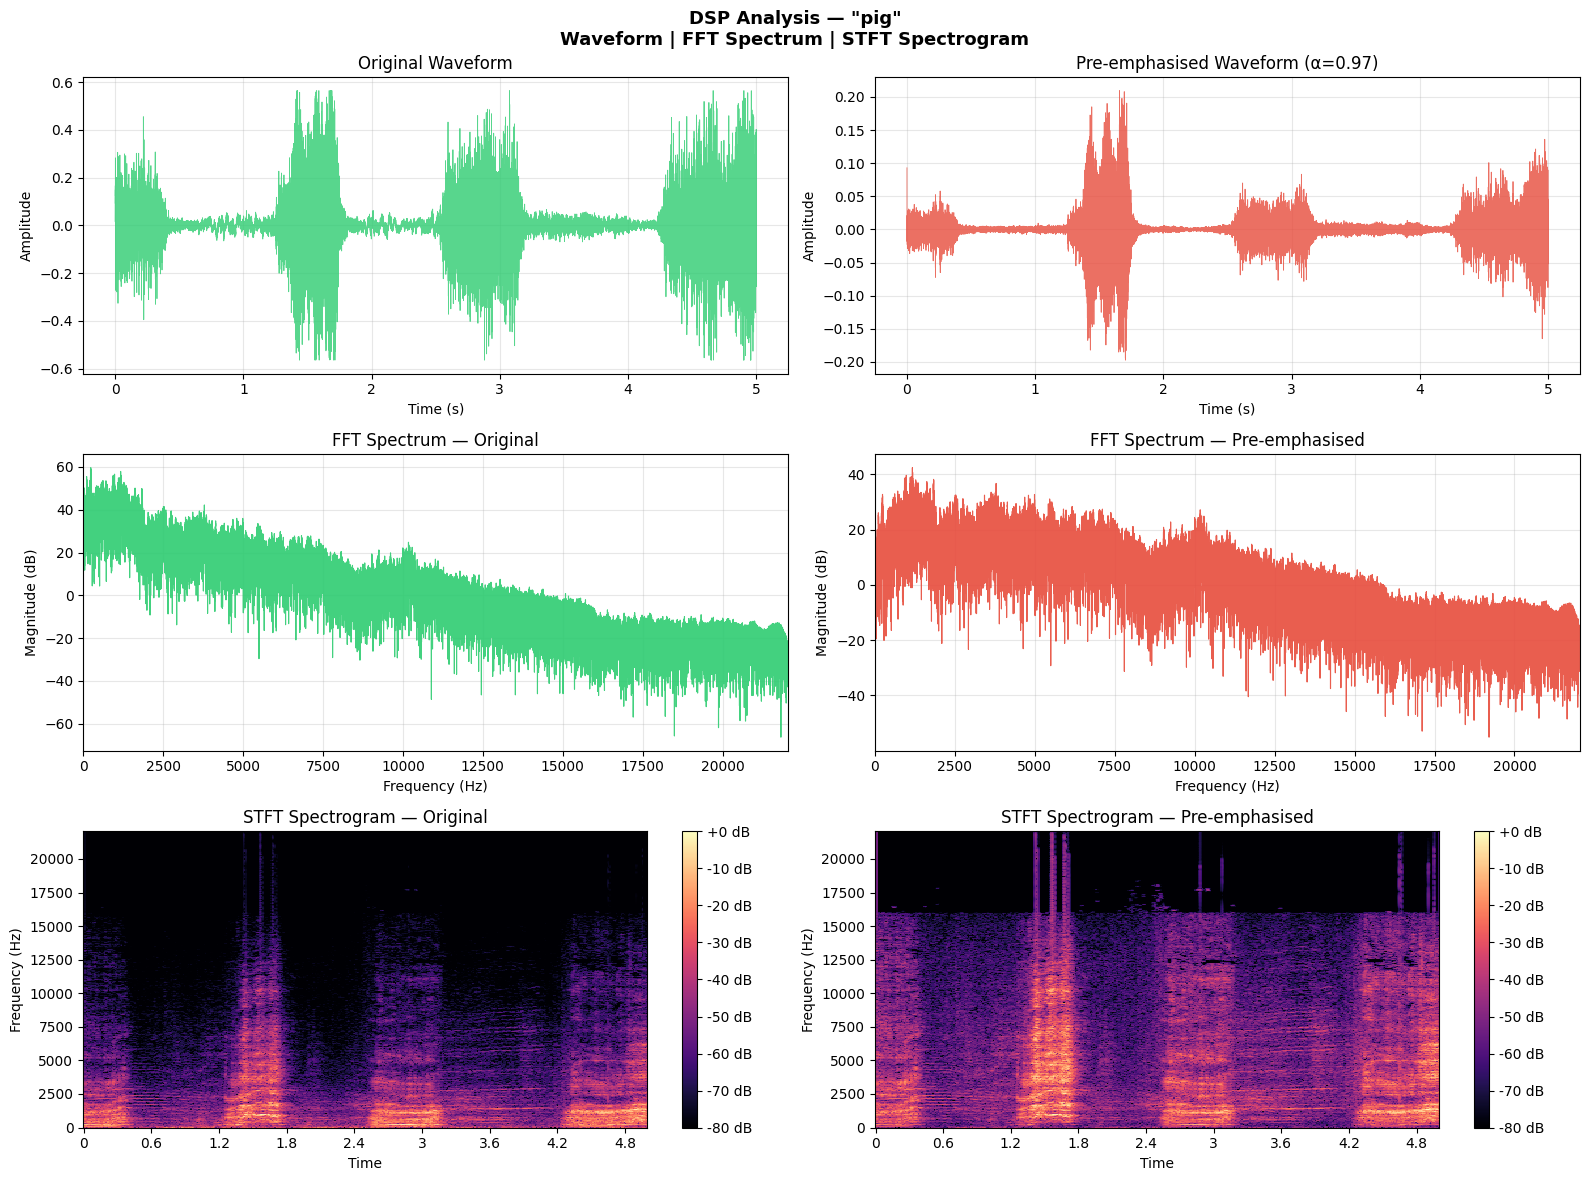

Saved  /content/drive/MyDrive/DSP Project/mfcc_noise_results/dsp_analysis.png


In [41]:
# ============================================================
# CELL 11 — DSP visualisation: waveform / FFT / STFT
# ============================================================
# Shows the effect of the pre-emphasis filter on one example
# clip across three domains: time, frequency, time-frequency.
# ============================================================

sample_wave  = test_waves[0]
sample_label = test_labels_audio[0]
sample_emph  = pre_emphasis(sample_wave)

print(f"  Example clip : {sample_label}")
print(f"  Signal shape : {sample_wave.shape}")
print(f"  Duration     : {len(sample_wave) / SAMPLE_RATE:.1f} s")

# ── Build 3×2 figure ─────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle(
    f'DSP Analysis — "{sample_label}"\n'
    f'Waveform | FFT Spectrum | STFT Spectrogram',
    fontsize=13, fontweight='bold',
)
t = np.linspace(0, len(sample_wave) / SAMPLE_RATE, len(sample_wave))

# Row 0: Waveforms
for ax, signal, title, color in zip(
    axes[0],
    [sample_wave, sample_emph],
    ["Original Waveform", "Pre-emphasised Waveform (α=0.97)"],
    ["#2ecc71", "#e74c3c"],
):
    ax.plot(t, signal, color=color, lw=0.6, alpha=0.8)
    ax.set(title=title, xlabel="Time (s)", ylabel="Amplitude")
    ax.grid(alpha=0.3)

# Row 1: FFT spectra
N           = len(sample_wave)
freqs       = np.fft.rfftfreq(N, d=1.0 / SAMPLE_RATE)
for ax, signal, title, color in zip(
    axes[1],
    [sample_wave, sample_emph],
    ["FFT Spectrum — Original", "FFT Spectrum — Pre-emphasised"],
    ["#2ecc71", "#e74c3c"],
):
    fft_db = 20 * np.log10(np.abs(np.fft.rfft(signal)) + 1e-10)
    ax.plot(freqs, fft_db, color=color, lw=0.8, alpha=0.9)
    ax.set(title=title, xlabel="Frequency (Hz)",
           ylabel="Magnitude (dB)", xlim=[0, SAMPLE_RATE / 2])
    ax.grid(alpha=0.3)

# Row 2: STFT spectrograms
for ax, signal, title in zip(
    axes[2],
    [sample_wave, sample_emph],
    ["STFT Spectrogram — Original", "STFT Spectrogram — Pre-emphasised"],
):
    D_db = librosa.amplitude_to_db(
        np.abs(librosa.stft(signal, n_fft=2048, hop_length=512)),
        ref=np.max,
    )
    img = librosa.display.specshow(
        D_db, sr=SAMPLE_RATE, hop_length=512,
        x_axis='time', y_axis='hz', ax=ax, cmap='magma',
    )
    ax.set(title=title, ylabel="Frequency (Hz)")
    fig.colorbar(img, ax=ax, format='%+2.0f dB')

plt.tight_layout()
dsp_path = f"{RESULTS_DIR}/dsp_analysis.png"
plt.savefig(dsp_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved  {dsp_path}")

---
## 8. Noise Addition Functions

In [42]:
# ============================================================
# CELL 12 — Noise generation functions
# ============================================================
# All three functions follow the same SNR formula:
#   P_noise = P_signal / 10^(SNR_dB / 10)
# so SNR values are comparable across noise types.
# ============================================================

def add_white_noise(signal: np.ndarray, snr_db: float) -> np.ndarray:
    """Add broadband white noise at the requested SNR.

    White noise has a flat power spectral density and is commonly
    used as a worst-case additive noise benchmark.

    Args:
        signal : clean waveform (float32)
        snr_db : target signal-to-noise ratio in dB
    Returns:
        Noisy waveform (float32)
    """
    signal_power = np.mean(signal ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise        = np.random.normal(0, np.sqrt(noise_power), len(signal))
    return (signal + noise).astype(np.float32)


def add_gaussian_noise(signal: np.ndarray, snr_db: float) -> np.ndarray:
    """Add zero-mean Gaussian noise at the requested SNR.

    Gaussian noise is statistically identical to white noise but
    is conceptually associated with thermal / sensor noise.
    Included as a separate condition to allow per-type analysis.

    Args:
        signal : clean waveform (float32)
        snr_db : target signal-to-noise ratio in dB
    Returns:
        Noisy waveform (float32)
    """
    signal_power = np.mean(signal ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise        = np.random.normal(
        loc=0.0, scale=np.sqrt(noise_power), size=len(signal)
    )
    return (signal + noise).astype(np.float32)


def add_low_snr_noise(signal: np.ndarray, snr_db: float) -> np.ndarray:
    """Add pink (1/f) noise at the requested SNR.

    Pink noise models real-world environmental backgrounds
    (wind, crowds, HVAC) that roll off at 3 dB/octave — more
    concentrated in low frequencies than white noise.

    Args:
        signal : clean waveform (float32)
        snr_db : target signal-to-noise ratio in dB
    Returns:
        Noisy waveform (float32)
    """
    signal_power = np.mean(signal ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))

    # Generate pink noise by shaping white noise in the frequency domain
    white   = np.random.randn(len(signal))
    freqs   = np.fft.rfftfreq(len(signal))
    freqs[0]= 1.0  # avoid division by zero at DC
    pink    = np.fft.irfft(
        np.fft.rfft(white) / np.sqrt(freqs),
        n=len(signal),
    )
    # Scale pink noise to target power
    pink_power  = np.mean(pink ** 2) + 1e-10
    pink_scaled = pink * np.sqrt(noise_power / pink_power)

    return (signal + pink_scaled).astype(np.float32)


print("Noise functions ready!")
print("   • add_white_noise    — flat power spectral density")
print("   • add_gaussian_noise — thermal / sensor noise model")
print("   • add_low_snr_noise  — pink (1/f) environmental noise")

Noise functions ready!
   • add_white_noise    — flat power spectral density
   • add_gaussian_noise — thermal / sensor noise model
   • add_low_snr_noise  — pink (1/f) environmental noise


---
## 9. Addaptive Winer Denoising Filter

In [43]:
# ============================================================
# CELL 13 — DSP Functions (Adaptive Wiener)
# ============================================================
def normalize_signal(signal: np.ndarray) -> np.ndarray:
    """Normalize to [-1, 1]."""
    max_val = np.max(np.abs(signal))
    if max_val > 0:
        return (signal / max_val).astype(np.float32)
    return signal.astype(np.float32)


def adaptive_wiener_filter(signal:     np.ndarray,
                           frame_size: int   = 512,
                           hop_size:   int   = 256,
                           floor:      float = 1e-8
                           ) -> np.ndarray:
    """
    Adaptive Wiener Filter — TIME DOMAIN.

    Per-frame gain:
        G[k] = max(0, 1 - σ²_noise / σ²_local[k])
    """
    n_samples  = len(signal)
    output     = np.zeros(n_samples, dtype=np.float32)
    weights    = np.zeros(n_samples, dtype=np.float32)
    window     = np.hanning(frame_size).astype(np.float32)

    frame_vars = []
    for start in range(0, n_samples - frame_size + 1,
                       hop_size):
        frame = signal[start: start + frame_size]
        frame_vars.append(np.var(frame))

    if not frame_vars:
        return signal

    noise_var = max(np.min(frame_vars), floor)

    for start in range(0, n_samples - frame_size + 1,
                       hop_size):
        frame     = signal[start: start + frame_size]
        local_var = max(np.var(frame), floor)
        gain      = max(0.0, 1.0 - noise_var / local_var)
        output[start: start + frame_size] += (
            gain * frame * window
        )
        weights[start: start + frame_size] += window

    weights = np.where(weights > floor, weights, 1.0)
    return (output / weights).astype(np.float32)


def dsp_pipeline(signal: np.ndarray,
                 sr:     int = 22050) -> np.ndarray:
    """
    Combined DSP Pipeline:
        Step 1: Normalize
        Step 2: Adaptive Wiener (time domain)
        Step 3: MMSE (frequency domain)
        Step 4: Re-normalize
    """
    y = normalize_signal(signal)
    y = adaptive_wiener_filter(y, frame_size=512,
                                  hop_size=256)
    y = mmse_filter(y, sr=sr, n_fft=512,
                    hop_length=128, noise_frames=10,
                    over_subtraction=1.2, floor=0.002)
    y = normalize_signal(y)
    return y


print(" DSP pipeline ready!")
print("   Step 1 → Normalize")
print("   Step 2 → Adaptive Wiener (time domain)")
print("   Step 3 → MMSE (frequency domain)")
print("   Step 4 → Re-normalize")

✅ DSP pipeline ready!
   Step 1 → Normalize
   Step 2 → Adaptive Wiener (time domain)
   Step 3 → MMSE (frequency domain)
   Step 4 → Re-normalize


---
## 10. Condition 1 — Clean Baseline

In [44]:
# ============================================================
# CELL 14 — Condition 1: clean audio (no noise, no DSP)
# ============================================================
# Evaluates the model on pre-scaled CSV features — the same
# representation the model was trained on.  This is the
# performance ceiling for Conditions 2 and 3.
# ============================================================

print("=" * 55)
print("  CONDITION 1 — Clean Audio Baseline")
print("=" * 55)

clean_preds = model.predict(X_test_scaled)
clean_acc   = accuracy_score(y_test, clean_preds)

print(f"   Clean accuracy : {clean_acc * 100:.2f}%")
print(f"   MATLAB target  : 53.0%")
print(f"\nBaseline established: {clean_acc * 100:.2f}%")

  CONDITION 1 — Clean Audio Baseline
   Clean accuracy : 53.00%
   MATLAB target  : 53.0%

Baseline established: 53.00%


---
## 11. Condition 2 — Noisy Audio

In [45]:
# ============================================================
# CELL 15 — Condition 2: noisy audio (no DSP preprocessing)
# ============================================================
# For each noise type × SNR level:
#   1. Add noise to each test waveform
#   2. Extract MFCC features
#   3. Apply the trained scaler
#   4. Predict and record accuracy
#
# Results are stored in `results[noise_type][snr]` for later
# comparison against Condition 3 (noisy + DSP).
# ============================================================

np.random.seed(RANDOM_SEED)   # reproducible noise generation

print("=" * 55)
print("  CONDITION 2 — Noisy Audio (no DSP)")
print("=" * 55)

# ── SNR levels per noise type ─────────────────────────────────
WHITE_SNR    = [15, 10,  5, 0]
GAUSSIAN_SNR = [15, 10,  5, 0]
LOW_SNR      = [ 5,  0, -5]

SNR_MAP = {
    "white"   : (WHITE_SNR,    add_white_noise),
    "gaussian": (GAUSSIAN_SNR, add_gaussian_noise),
    "low_snr" : (LOW_SNR,      add_low_snr_noise),
}

results = {key: {} for key in SNR_MAP}


def predict_noisy(waves:    np.ndarray,
                  labels:   np.ndarray,
                  noise_fn,
                  snr:      float,
                  desc:     str = "") -> tuple:
    """Add noise → extract features → scale → predict.

    Returns:
        (accuracy, predictions, noisy_waveforms)
    """
    noisy_waves = np.array([noise_fn(w, snr) for w in waves])
    features    = np.array([
        extract_features_from_wave(w)
        for w in noisy_waves
    ], dtype=np.float32)
    features = scaler.transform(features)
    preds    = model.predict(features)
    acc      = accuracy_score(labels, preds)
    if desc:
        print(f"   {desc}: {acc * 100:.2f}%")
    return acc, preds, noisy_waves


# ── Run all noise × SNR combinations ─────────────────────────
noise_display = {
    "white"   : "WHITE NOISE",
    "gaussian": "GAUSSIAN NOISE",
    "low_snr" : "LOW-SNR (Pink Noise)",
}

for noise_key, (snr_levels, noise_fn) in SNR_MAP.items():
    print(f"\n {noise_display[noise_key]}:")
    for snr in snr_levels:
        acc, preds, noisy = predict_noisy(
            test_waves, test_labels_audio, noise_fn, snr,
            desc=f"  SNR={snr:+3d} dB",
        )
        results[noise_key][snr] = {
            "noisy_acc"   : acc,
            "noisy_preds" : preds,
            "noisy_waves" : noisy,
        }

print("\n Condition 2 complete!")

  CONDITION 2 — Noisy Audio (no DSP)

 WHITE NOISE:
     SNR=+15 dB: 34.75%
     SNR=+10 dB: 23.75%
     SNR= +5 dB: 10.25%
     SNR= +0 dB: 3.00%

 GAUSSIAN NOISE:
     SNR=+15 dB: 35.00%
     SNR=+10 dB: 22.75%
     SNR= +5 dB: 13.00%
     SNR= +0 dB: 3.25%

 LOW-SNR (Pink Noise):
     SNR= +5 dB: 11.75%
     SNR= +0 dB: 3.75%
     SNR= -5 dB: 2.00%

 Condition 2 complete!


---
## 12. Condition 3 — Noisy + DSP

In [47]:
# ============================================================
# CELL 16 — CONDITION 3: Noisy + DSP (Adaptive Wiener Only)
# ============================================================
np.random.seed(45)

print("=" * 55)
print("  CONDITION 3 — Noisy + DSP")
print("=" * 55)
print("  Pipeline: Noise → Normalize → Adaptive Wiener → Re-normalize → MFCC → Scale")


def dsp_pipeline_wiener_only(signal, sr=SAMPLE_RATE):
    """
    DSP Pipeline:
        Step 1: Normalize to [-1, 1]
        Step 2: Adaptive Wiener Filter (time domain)
        Step 3: Re-normalize

    Pre-emphasis is analyzed in Cell 7 but excluded here
    to maintain consistency with the trained model's
    feature space and avoid amplifying residual noise.
    """
    y = normalize_signal(signal)
    y = adaptive_wiener_filter(y, frame_size=512, hop_size=256)
    y = normalize_signal(y)
    return y


def predict_denoised(noisy_waves, labels, desc=""):
    """Apply Wiener DSP → extract features → scale → predict."""
    cleaned = np.array([
        dsp_pipeline_wiener_only(w, sr=SAMPLE_RATE)
        for w in tqdm(noisy_waves, desc=f"  DSP {desc}", leave=False)
    ])
    features = np.array([
        extract_features_from_wave(w, sr=SAMPLE_RATE)   # ← was extract_mfcc_like_csv
        for w in cleaned
    ], dtype=np.float32)
    features = scaler.transform(features)
    preds    = model.predict(features)
    acc      = accuracy_score(labels, preds)
    print(f"   {desc}: {acc*100:.2f}%")
    return acc, preds, cleaned


# ── White Noise + DSP ─────────────────────────────────────────
print("\n🔧 WHITE NOISE + DSP:")
for snr in WHITE_SNR:
    acc, preds, cleaned = predict_denoised(
        results["white"][snr]["noisy_waves"],
        test_labels_audio,
        desc=f"SNR={snr:+3d}dB"
    )
    results["white"][snr]["dsp_acc"]     = acc
    results["white"][snr]["dsp_preds"]   = preds
    results["white"][snr]["clean_waves"] = cleaned

# ── Gaussian Noise + DSP ──────────────────────────────────────
print("\n🔧 GAUSSIAN NOISE + DSP:")
for snr in GAUSSIAN_SNR:
    acc, preds, cleaned = predict_denoised(
        results["gaussian"][snr]["noisy_waves"],
        test_labels_audio,
        desc=f"SNR={snr:+3d}dB"
    )
    results["gaussian"][snr]["dsp_acc"]     = acc
    results["gaussian"][snr]["dsp_preds"]   = preds
    results["gaussian"][snr]["clean_waves"] = cleaned

# ── Low SNR + DSP ─────────────────────────────────────────────
print("\n🔧 LOW SNR + DSP:")
for snr in LOW_SNR:
    acc, preds, cleaned = predict_denoised(
        results["low_snr"][snr]["noisy_waves"],
        test_labels_audio,
        desc=f"SNR={snr:+3d}dB"
    )
    results["low_snr"][snr]["dsp_acc"]     = acc
    results["low_snr"][snr]["dsp_preds"]   = preds
    results["low_snr"][snr]["clean_waves"] = cleaned

print("\n Condition 3 complete!")

  CONDITION 3 — Noisy + DSP
  Pipeline: Noise → Normalize → Adaptive Wiener → Re-normalize → MFCC → Scale

🔧 WHITE NOISE + DSP:


   SNR=+15dB: 39.00%


   SNR=+10dB: 33.75%


   SNR= +5dB: 22.25%


   SNR= +0dB: 9.00%

🔧 GAUSSIAN NOISE + DSP:


...

   SNR= +5dB: 20.00%


   SNR= +0dB: 10.25%

🔧 LOW SNR + DSP:


   SNR= +5dB: 17.50%


   SNR= +0dB: 4.75%


   SNR= -5dB: 2.25%

✅ Condition 3 complete!


---
## 13. Results Table

In [48]:
# ============================================================
# CELL 17 — Compile and export results table
# ============================================================

rows = []
for noise_key, (snr_levels, _) in SNR_MAP.items():
    for snr in snr_levels:
        vals = results[noise_key][snr]
        rows.append({
            "Noise Type"     : noise_key.replace("_", " ").title(),
            "SNR (dB)"       : snr,
            "Clean (%)"      : round(clean_acc * 100, 2),
            "Noisy (%)"      : round(vals["noisy_acc"] * 100, 2),
            "Noisy+DSP (%)"  : round(vals["dsp_acc"]   * 100, 2),
            "DSP Δ (pp)"     : round((vals["dsp_acc"] - vals["noisy_acc"]) * 100, 2),
        })

results_df = (
    pd.DataFrame(rows)
    .sort_values(["Noise Type", "SNR (dB)"], ascending=[True, False])
    .reset_index(drop=True)
)

print("=" * 65)
print("  RESULTS — Clean vs Noisy vs Noisy+DSP")
print("=" * 65)
print(results_df.to_string(index=False))

csv_out = f"{RESULTS_DIR}/mfcc_noise_results.csv"
results_df.to_csv(csv_out, index=False)
print(f"\n Saved → {csv_out}")

  RESULTS — Clean vs Noisy vs Noisy+DSP
Noise Type  SNR (dB)  Clean (%)  Noisy (%)  Noisy+DSP (%)  DSP Δ (pp)
  Gaussian        15       53.0      35.00          39.00        4.00
  Gaussian        10       53.0      22.75          31.75        9.00
  Gaussian         5       53.0      13.00          20.00        7.00
  Gaussian         0       53.0       3.25          10.25        7.00
   Low Snr         5       53.0      11.75          17.50        5.75
   Low Snr         0       53.0       3.75           4.75        1.00
   Low Snr        -5       53.0       2.00           2.25        0.25
     White        15       53.0      34.75          39.00        4.25
     White        10       53.0      23.75          33.75       10.00
     White         5       53.0      10.25          22.25       12.00
     White         0       53.0       3.00           9.00        6.00

 Saved → /content/drive/MyDrive/DSP Project/mfcc_noise_results/mfcc_noise_results.csv


---
## 14. Visualisations

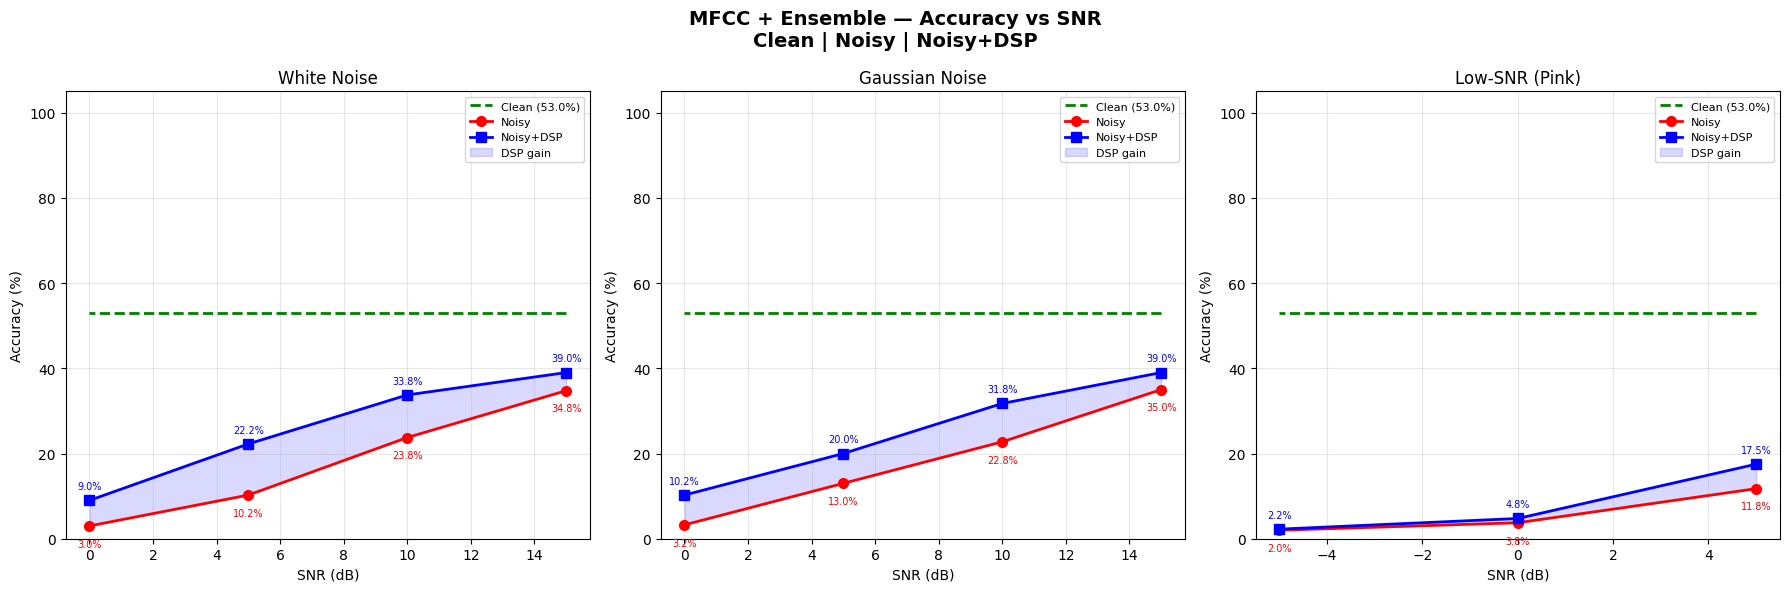

Saved → /content/drive/MyDrive/DSP Project/mfcc_noise_results/mfcc_accuracy_vs_snr.png


In [49]:
# ============================================================
# CELL 18 — Line plots: Accuracy vs SNR
# ============================================================
# One subplot per noise type.  The shaded band between Noisy
# and Noisy+DSP lines shows the DSP recovery region.
# ============================================================

NOISE_CONFIGS = [
    ("white",    "White Noise",    WHITE_SNR),
    ("gaussian", "Gaussian Noise", GAUSSIAN_SNR),
    ("low_snr",  "Low-SNR (Pink)",  LOW_SNR),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'MFCC + Ensemble — Accuracy vs SNR\nClean | Noisy | Noisy+DSP',
    fontsize=14, fontweight='bold',
)

for ax, (noise_key, noise_label, snr_levels) in zip(axes, NOISE_CONFIGS):
    noisy_accs = [results[noise_key][s]["noisy_acc"] * 100 for s in snr_levels]
    dsp_accs   = [results[noise_key][s]["dsp_acc"]   * 100 for s in snr_levels]
    clean_line = [clean_acc * 100] * len(snr_levels)

    ax.plot(snr_levels, clean_line, 'g--', lw=2,
            label=f'Clean ({clean_acc * 100:.1f}%)')
    ax.plot(snr_levels, noisy_accs, 'r-o', lw=2,
            label='Noisy', markersize=7)
    ax.plot(snr_levels, dsp_accs,   'b-s', lw=2,
            label='Noisy+DSP', markersize=7)
    ax.fill_between(snr_levels, noisy_accs, dsp_accs,
                    alpha=0.15, color='blue', label='DSP gain')

    # Annotate data points
    for snr, n, d in zip(snr_levels, noisy_accs, dsp_accs):
        ax.annotate(f'{n:.1f}%', (snr, n),
                    textcoords="offset points", xytext=(0, -15),
                    fontsize=7, color='red', ha='center')
        ax.annotate(f'{d:.1f}%', (snr, d),
                    textcoords="offset points", xytext=(0,  8),
                    fontsize=7, color='blue', ha='center')

    ax.set(xlabel='SNR (dB)', ylabel='Accuracy (%)',
           title=noise_label, ylim=(0, 105))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
p1 = f"{RESULTS_DIR}/mfcc_accuracy_vs_snr.png"
plt.savefig(p1, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {p1}")

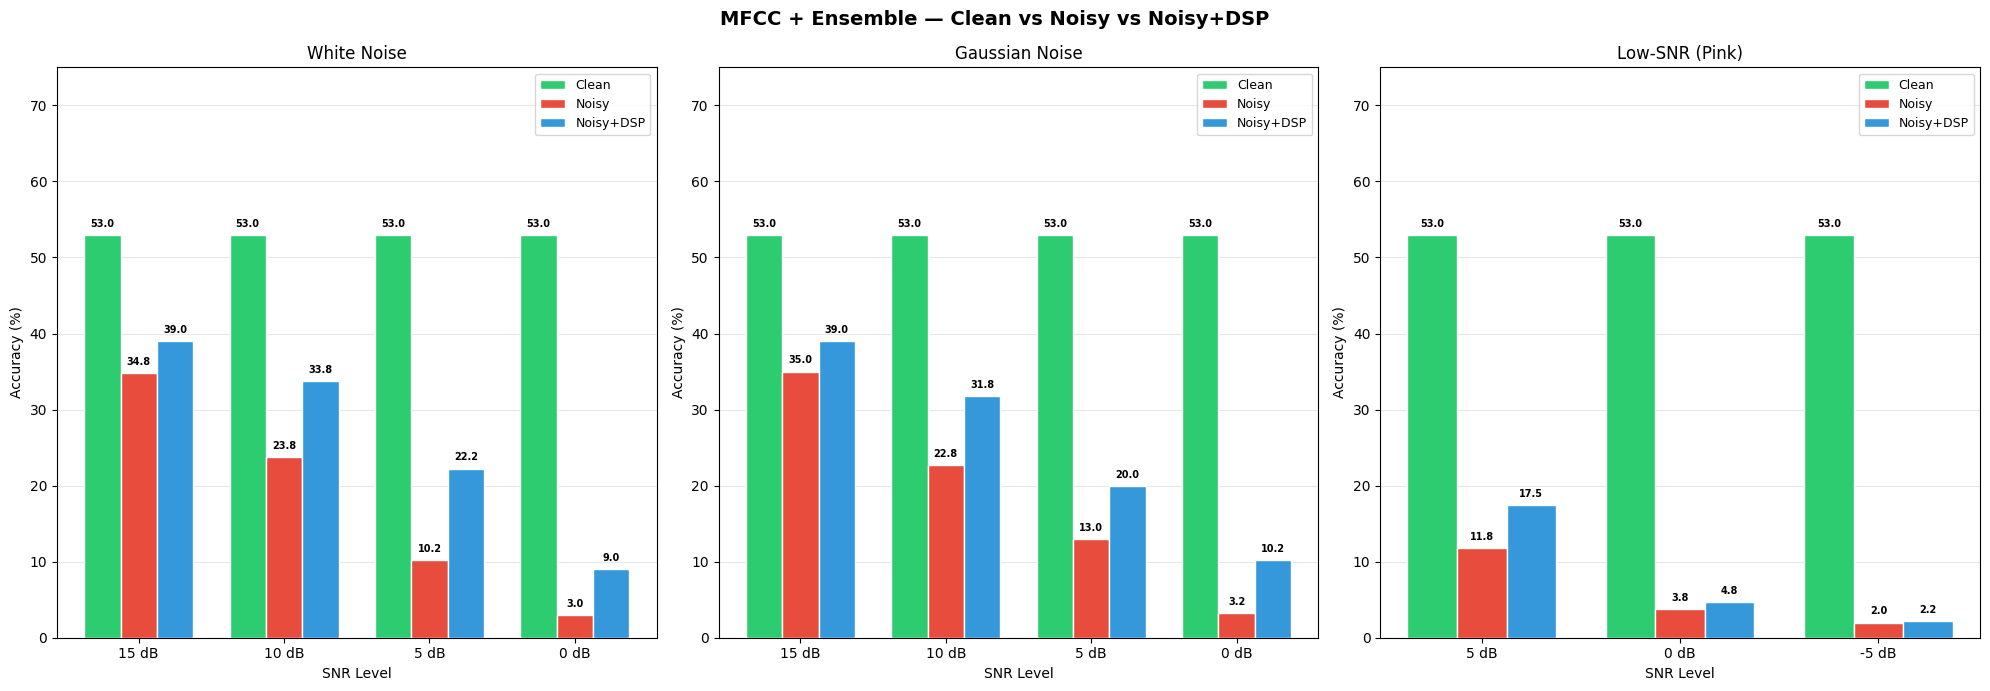

Saved → /content/drive/MyDrive/DSP Project/mfcc_noise_results/mfcc_grouped_bar.png


In [50]:
# ============================================================
# CELL 19 — Grouped bar chart: Clean vs Noisy vs Noisy+DSP
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    'MFCC + Ensemble — Clean vs Noisy vs Noisy+DSP',
    fontsize=14, fontweight='bold',
)

BAR_W = 0.25   # width of each bar group element

for ax, (noise_key, noise_label, snr_levels) in zip(axes, NOISE_CONFIGS):
    x          = np.arange(len(snr_levels))
    clean_vals = [clean_acc * 100] * len(snr_levels)
    noisy_vals = [results[noise_key][s]["noisy_acc"] * 100 for s in snr_levels]
    dsp_vals   = [results[noise_key][s]["dsp_acc"]   * 100 for s in snr_levels]

    b_clean = ax.bar(x - BAR_W, clean_vals, BAR_W,
                     label='Clean',     color='#2ecc71', edgecolor='white', zorder=3)
    b_noisy = ax.bar(x,         noisy_vals, BAR_W,
                     label='Noisy',     color='#e74c3c', edgecolor='white', zorder=3)
    b_dsp   = ax.bar(x + BAR_W, dsp_vals,   BAR_W,
                     label='Noisy+DSP', color='#3498db', edgecolor='white', zorder=3)

    # Label each bar with its height
    for bars in (b_clean, b_noisy, b_dsp):
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.8, f'{h:.1f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold',
            )

    ax.set(
        xlabel='SNR Level', ylabel='Accuracy (%)',
        title=noise_label, ylim=(0, 75),
        xticks=x, xticklabels=[f"{s} dB" for s in snr_levels],
    )
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
p2 = f"{RESULTS_DIR}/mfcc_grouped_bar.png"
plt.savefig(p2, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {p2}")

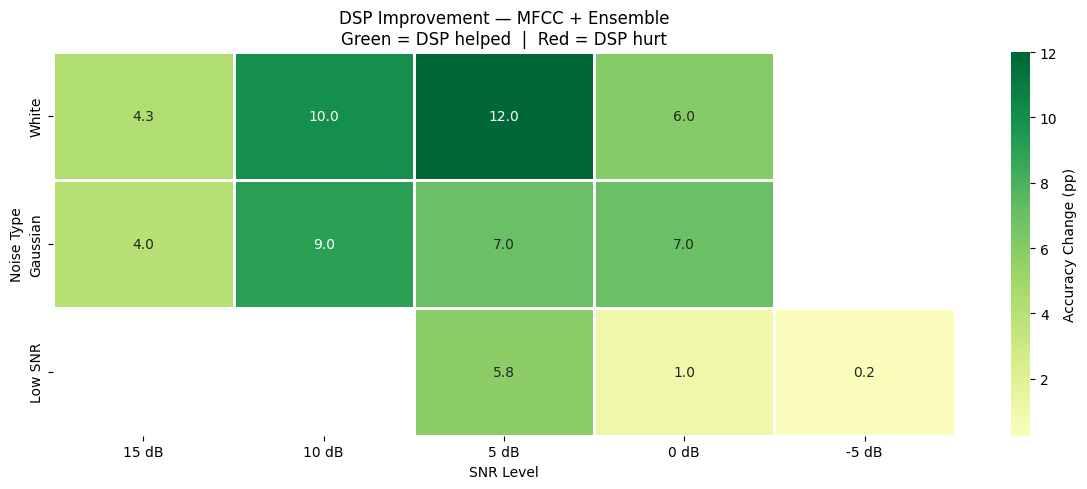

Saved → /content/drive/MyDrive/DSP Project/mfcc_noise_results/mfcc_dsp_heatmap.png


In [51]:
# ============================================================
# CELL 20 — DSP improvement heatmap
# ============================================================
# Green cells = DSP improved accuracy; red cells = DSP hurt.
# NaN cells (grey) = that SNR level was not tested for that
# noise type (e.g. −5 dB only tested for Low-SNR noise).
# ============================================================

ALL_SNRS    = [15, 10, 5, 0, -5]
NOISE_KEYS  = ["white", "gaussian", "low_snr"]
NOISE_NAMES = ["White", "Gaussian", "Low SNR"]

imp_matrix = np.full((len(NOISE_KEYS), len(ALL_SNRS)), np.nan)

for i, noise_key in enumerate(NOISE_KEYS):
    for j, snr in enumerate(ALL_SNRS):
        snr_levels = SNR_MAP[noise_key][0]
        if snr in snr_levels:
            imp_matrix[i, j] = (
                results[noise_key][snr]["dsp_acc"]
                - results[noise_key][snr]["noisy_acc"]
            ) * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    imp_matrix,
    mask=np.isnan(imp_matrix),
    annot=True, fmt=".1f",
    cmap="RdYlGn", center=0,
    xticklabels=[f"{s} dB" for s in ALL_SNRS],
    yticklabels=NOISE_NAMES,
    linewidths=1, ax=ax,
    cbar_kws={'label': 'Accuracy Change (pp)'},
)
ax.set(
    title=(
        'DSP Improvement — MFCC + Ensemble\n'
        'Green = DSP helped  |  Red = DSP hurt'
    ),
    xlabel='SNR Level', ylabel='Noise Type',
)
plt.tight_layout()
p3 = f"{RESULTS_DIR}/mfcc_dsp_heatmap.png"
plt.savefig(p3, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {p3}")

---
## 15. Confusion Matrices

In [52]:
# ============================================================
# CELL 21 — Resolve ground-truth labels for confusion matrices
# ============================================================
# Noise experiments use raw audio labels (category strings).
# Verify these match the model's class set before plotting.
# ============================================================

if set(model.classes_) == set(np.unique(test_labels_audio)):
    NOISE_LABELS = test_labels_audio
    print("NOISE_LABELS = audio category names")
elif set(model.classes_) == set(np.unique(y_test)):
    NOISE_LABELS = y_test
    print("NOISE_LABELS = CSV label column")
else:
    NOISE_LABELS = y_test
    print("Class set mismatch — defaulting to y_test")

CLASS_NAMES = list(model.classes_)
print(f"   NOISE_LABELS shape : {NOISE_LABELS.shape}")
print(f"   Sample             : {NOISE_LABELS[:3]}")
print(f"   Model classes (3)  : {model.classes_[:3]}")

NOISE_LABELS = audio category names
   NOISE_LABELS shape : (400,)
   Sample             : ['pig' 'pig' 'pig']
   Model classes (3)  : ['airplane' 'breathing' 'brushing_teeth']


In [53]:
# ============================================================
# CELL 22 — Confusion matrix helper function
# ============================================================

def plot_confusion_matrix(preds:     np.ndarray,
                          labels:    np.ndarray,
                          title:     str,
                          save_path: str) -> np.ndarray:
    """Plot a 50-class confusion matrix heatmap and save to disk.

    Args:
        preds     : predicted class labels
        labels    : true class labels
        title     : figure title
        save_path : output file path (PNG)

    Returns:
        Confusion matrix as a (n_classes, n_classes) ndarray.
    """
    cm  = confusion_matrix(labels, preds, labels=CLASS_NAMES)
    acc = np.trace(cm) / np.sum(cm) * 100

    fig, ax = plt.subplots(figsize=(22, 20))
    sns.heatmap(
        cm,
        annot=False, cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        linewidths=0.3, ax=ax,
    )
    ax.set(
        xlabel='Predicted Label', ylabel='True Label',
        title=f'{title}\nAccuracy: {acc:.2f}%',
    )
    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(rotation=0,  fontsize=7)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {save_path}")
    return cm


print("plot_confusion_matrix helper ready.")

plot_confusion_matrix helper ready.



White Noise SNR=+5 dB (No DSP) …


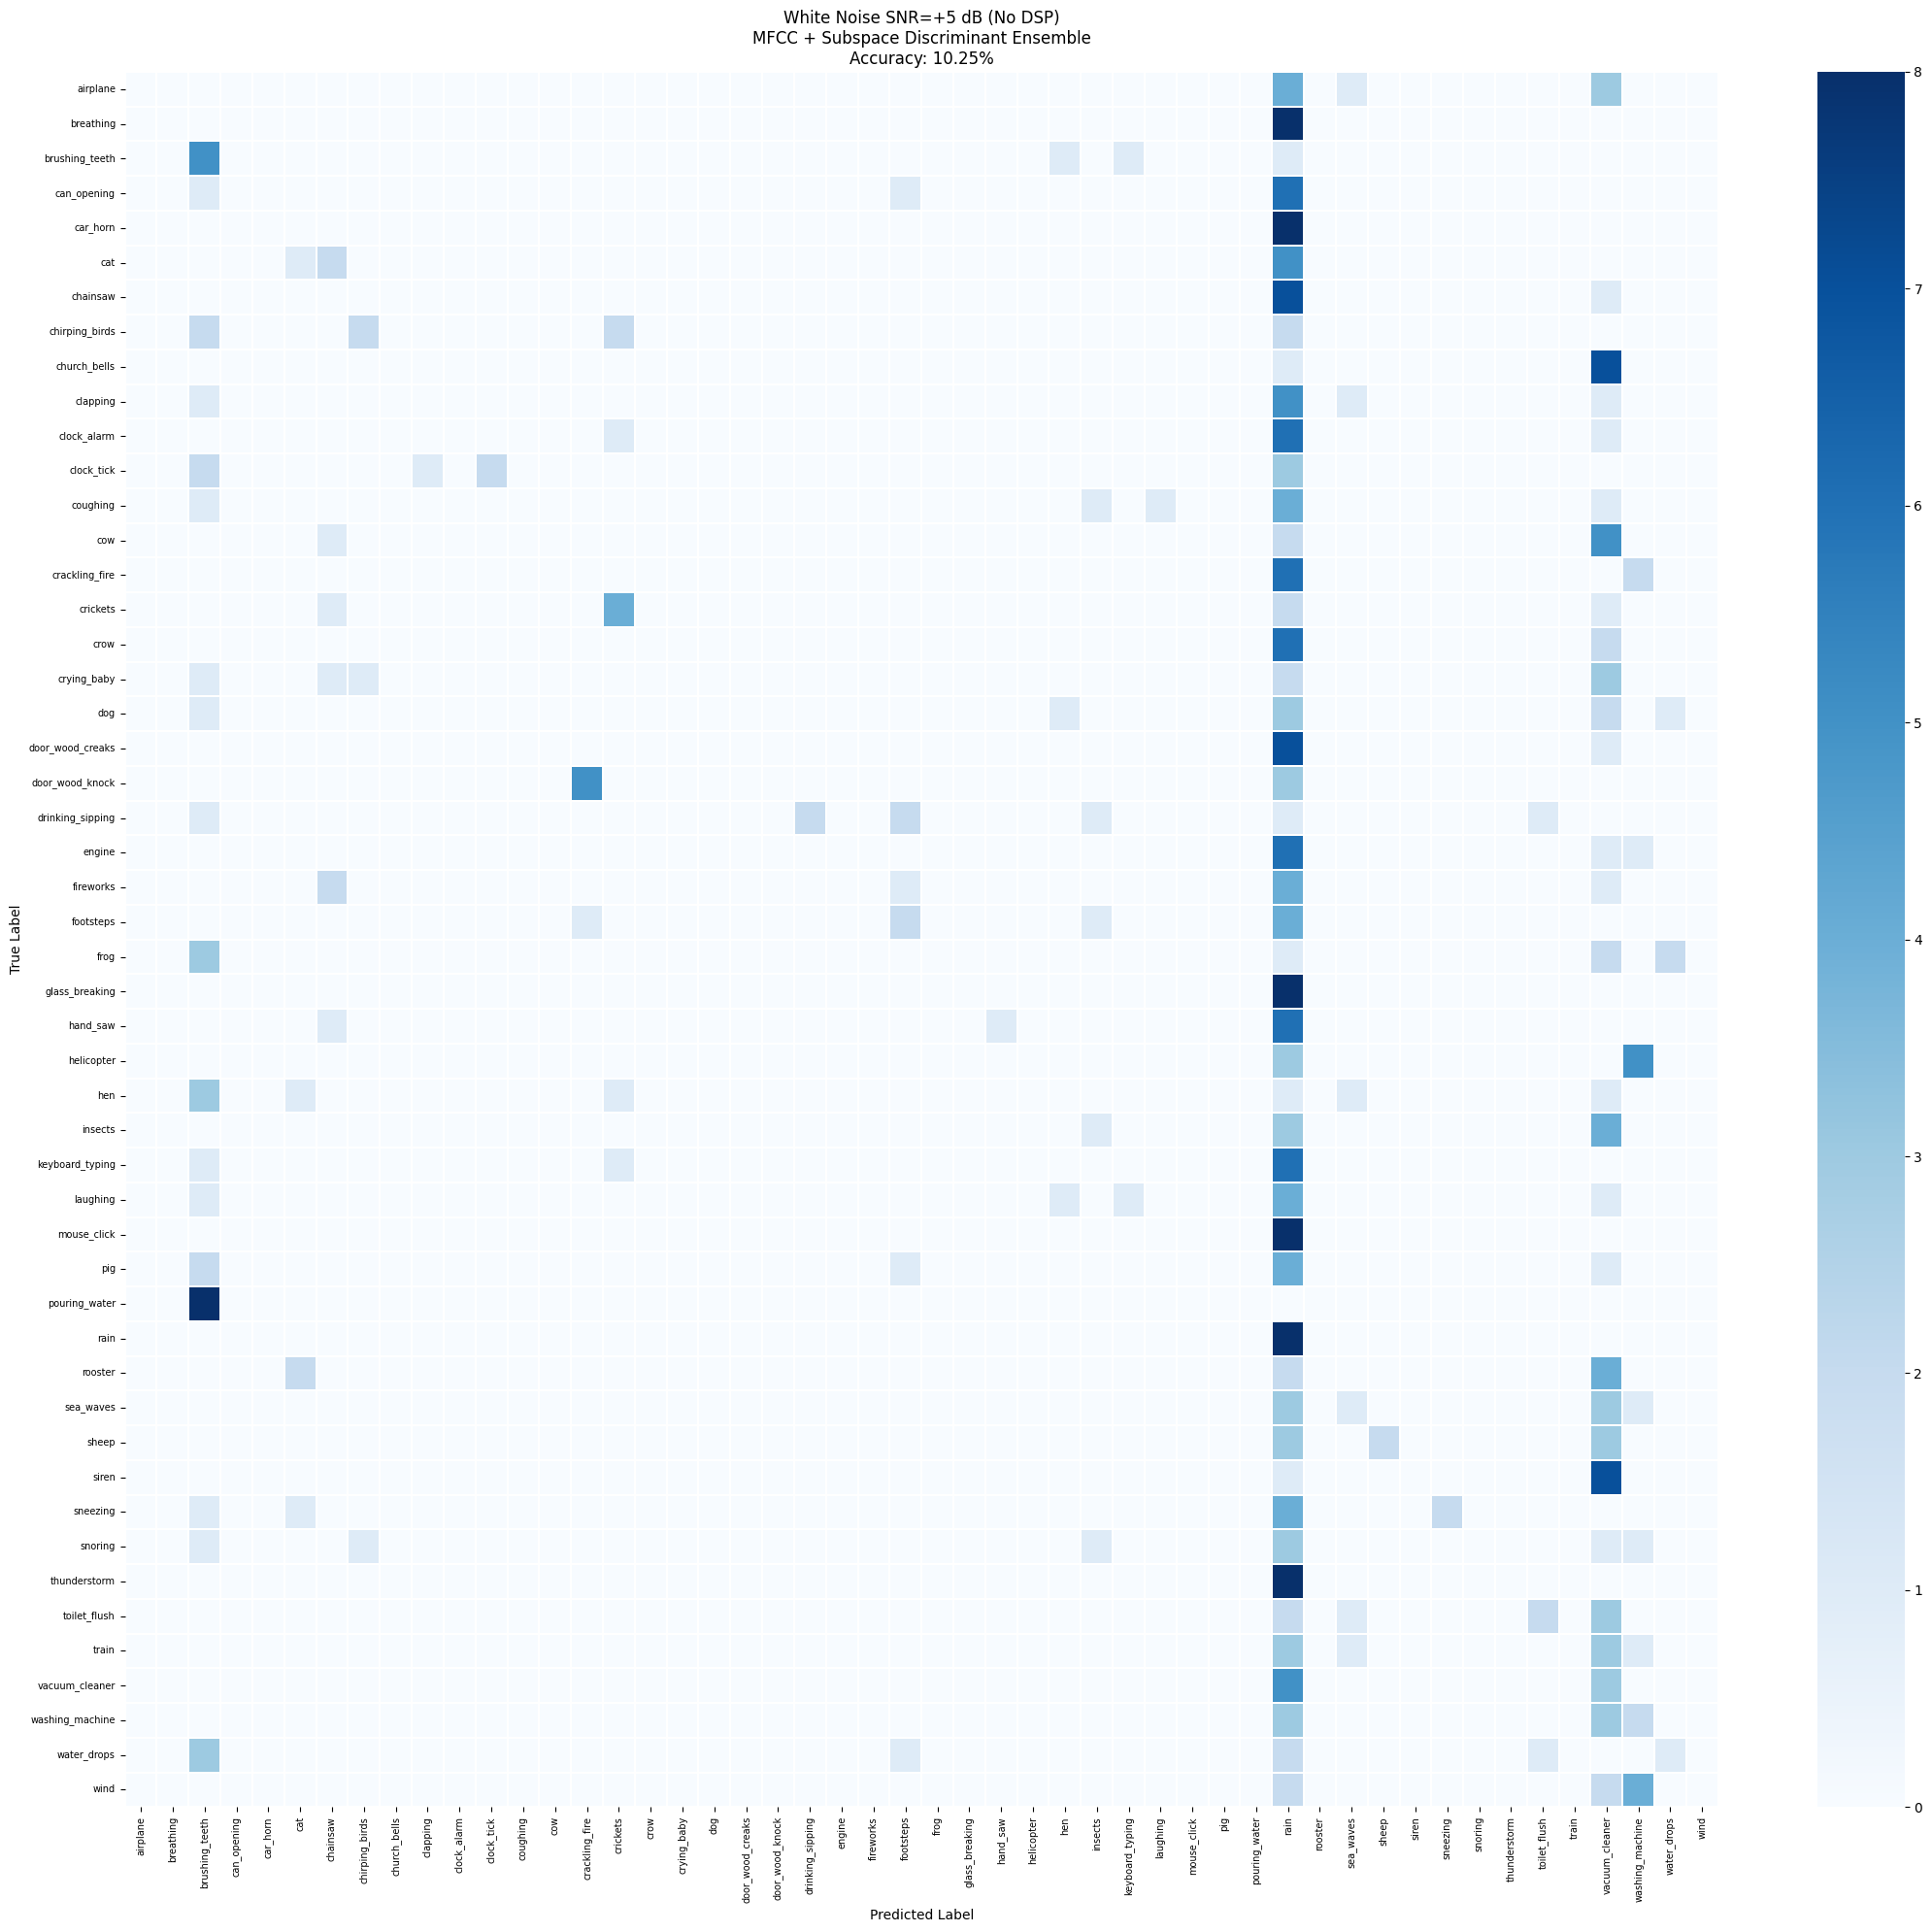

Saved → /content/drive/MyDrive/DSP Project/mfcc_noise_results/cm_white_5db_noisy.png

White Noise SNR=+5 dB + DSP …


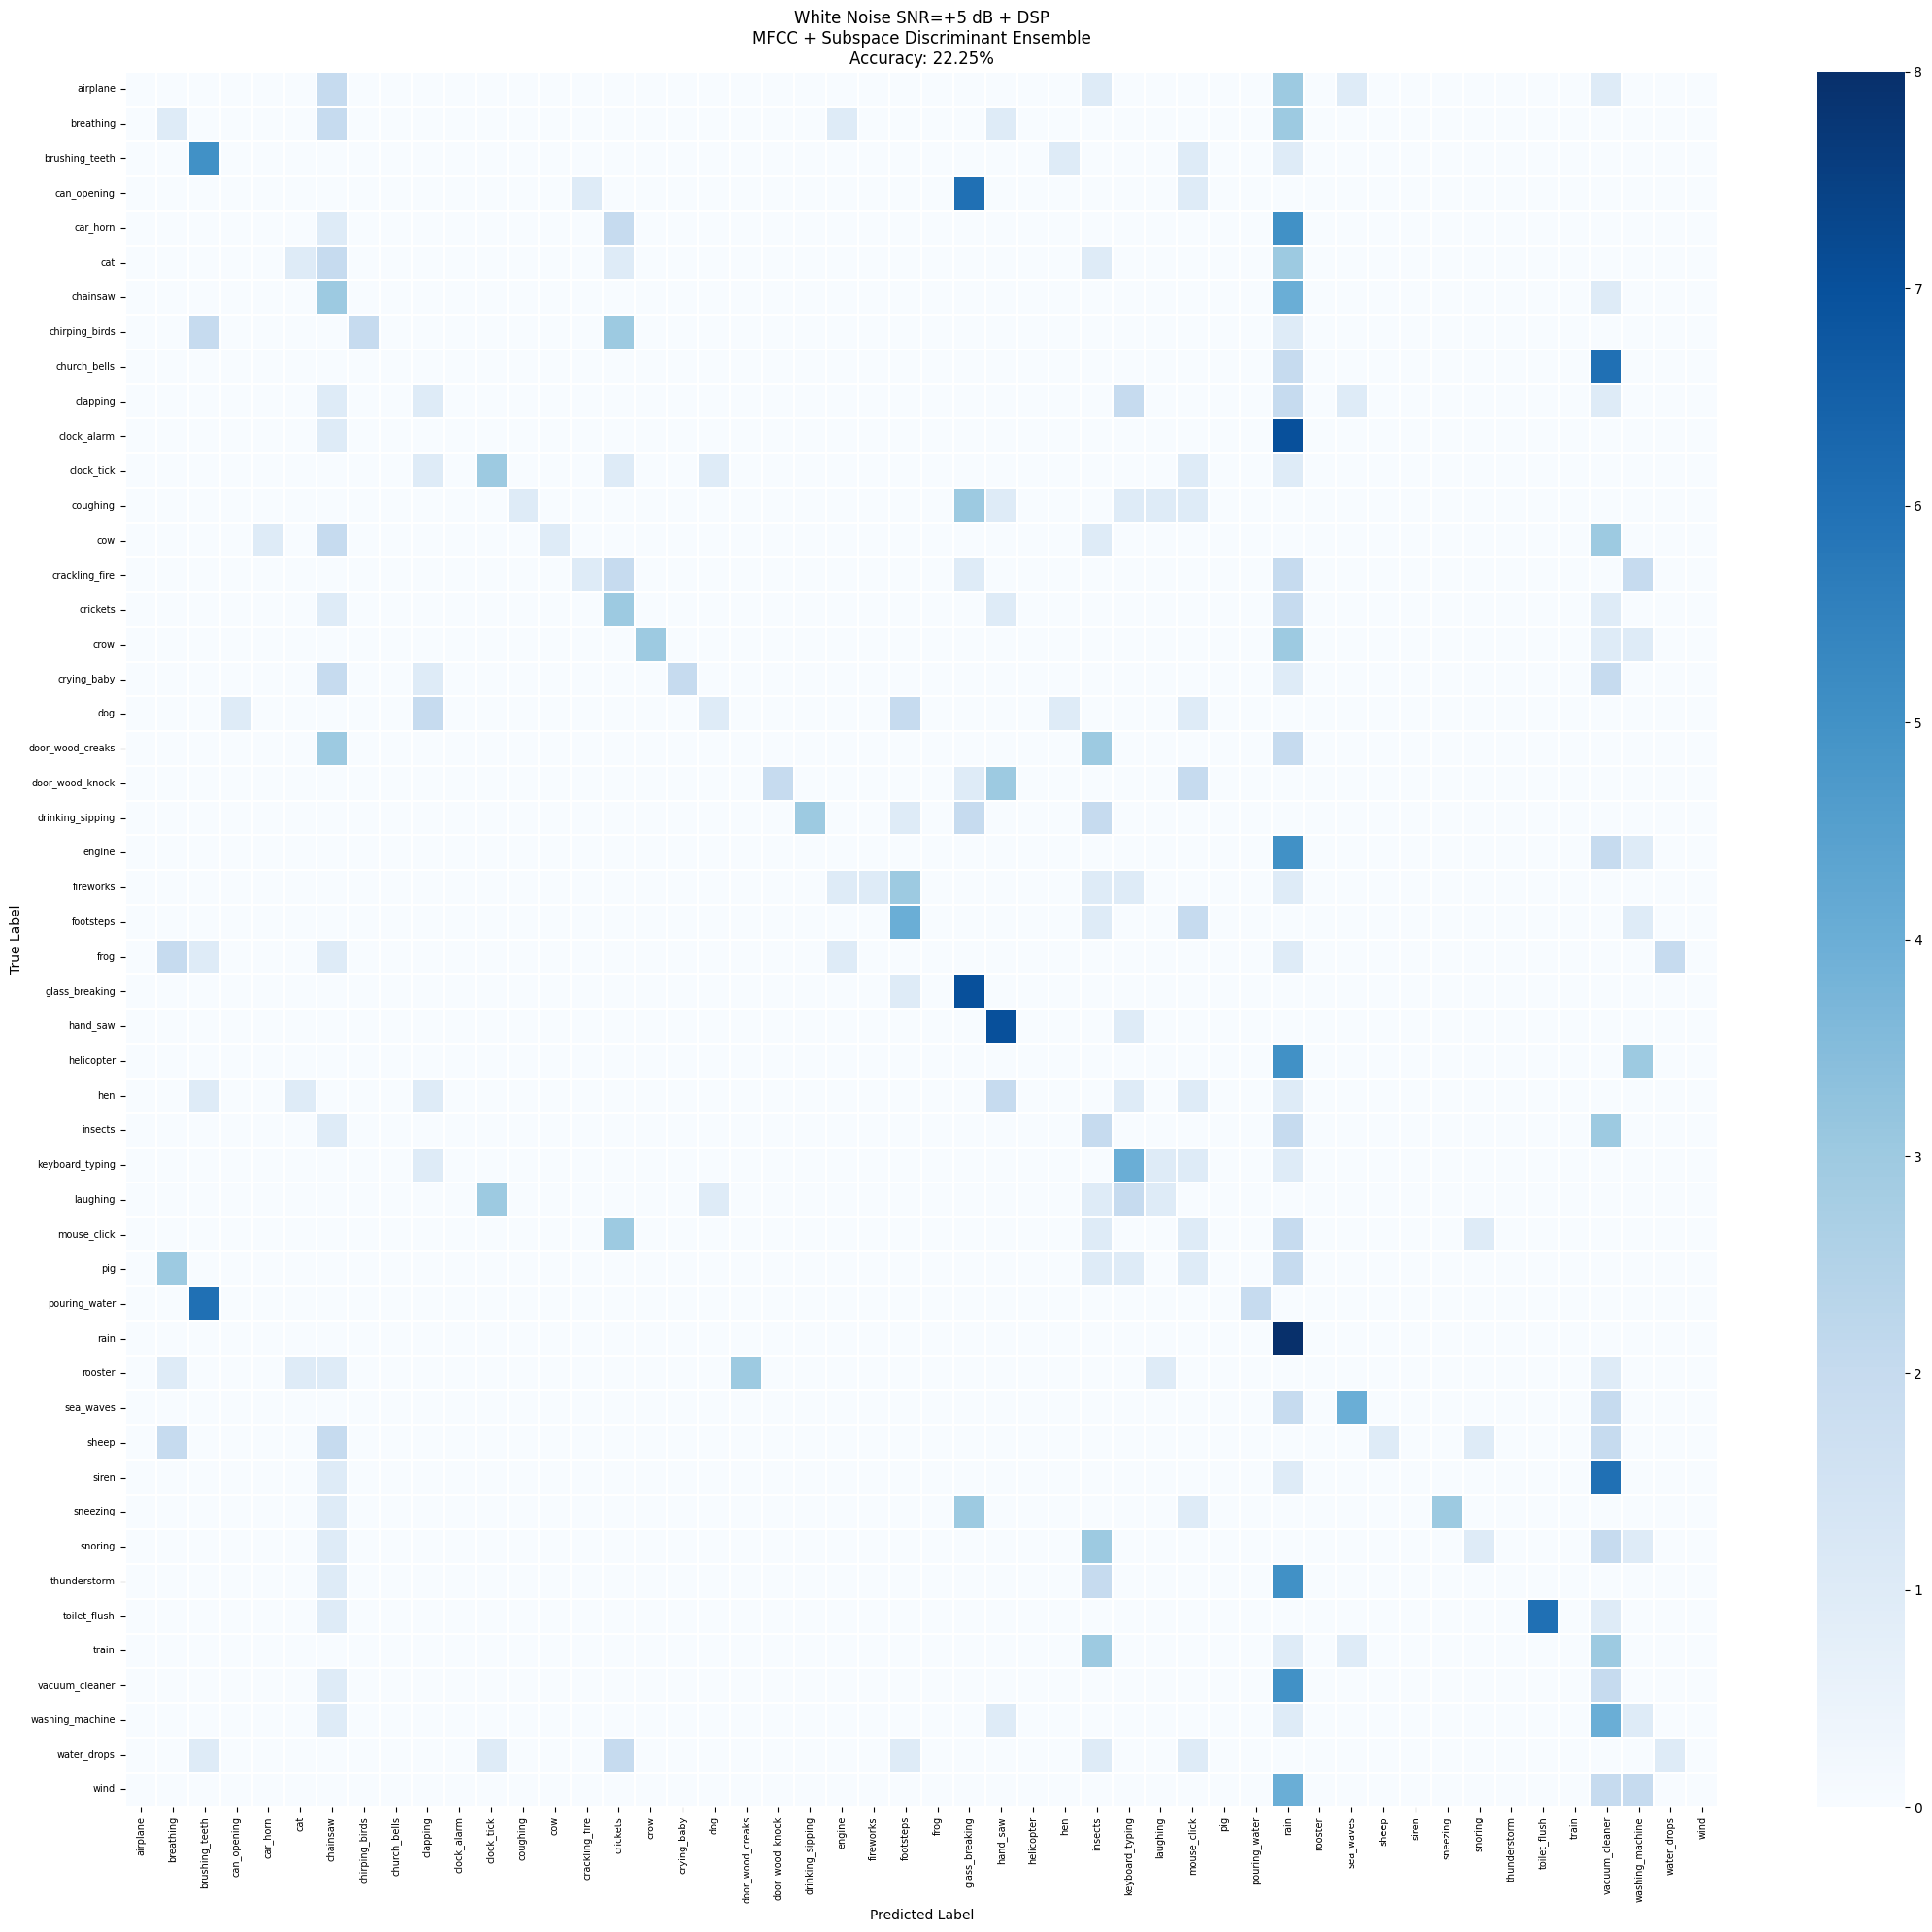

Saved → /content/drive/MyDrive/DSP Project/mfcc_noise_results/cm_white_5db_dsp.png

Low SNR=−5 dB (No DSP) …


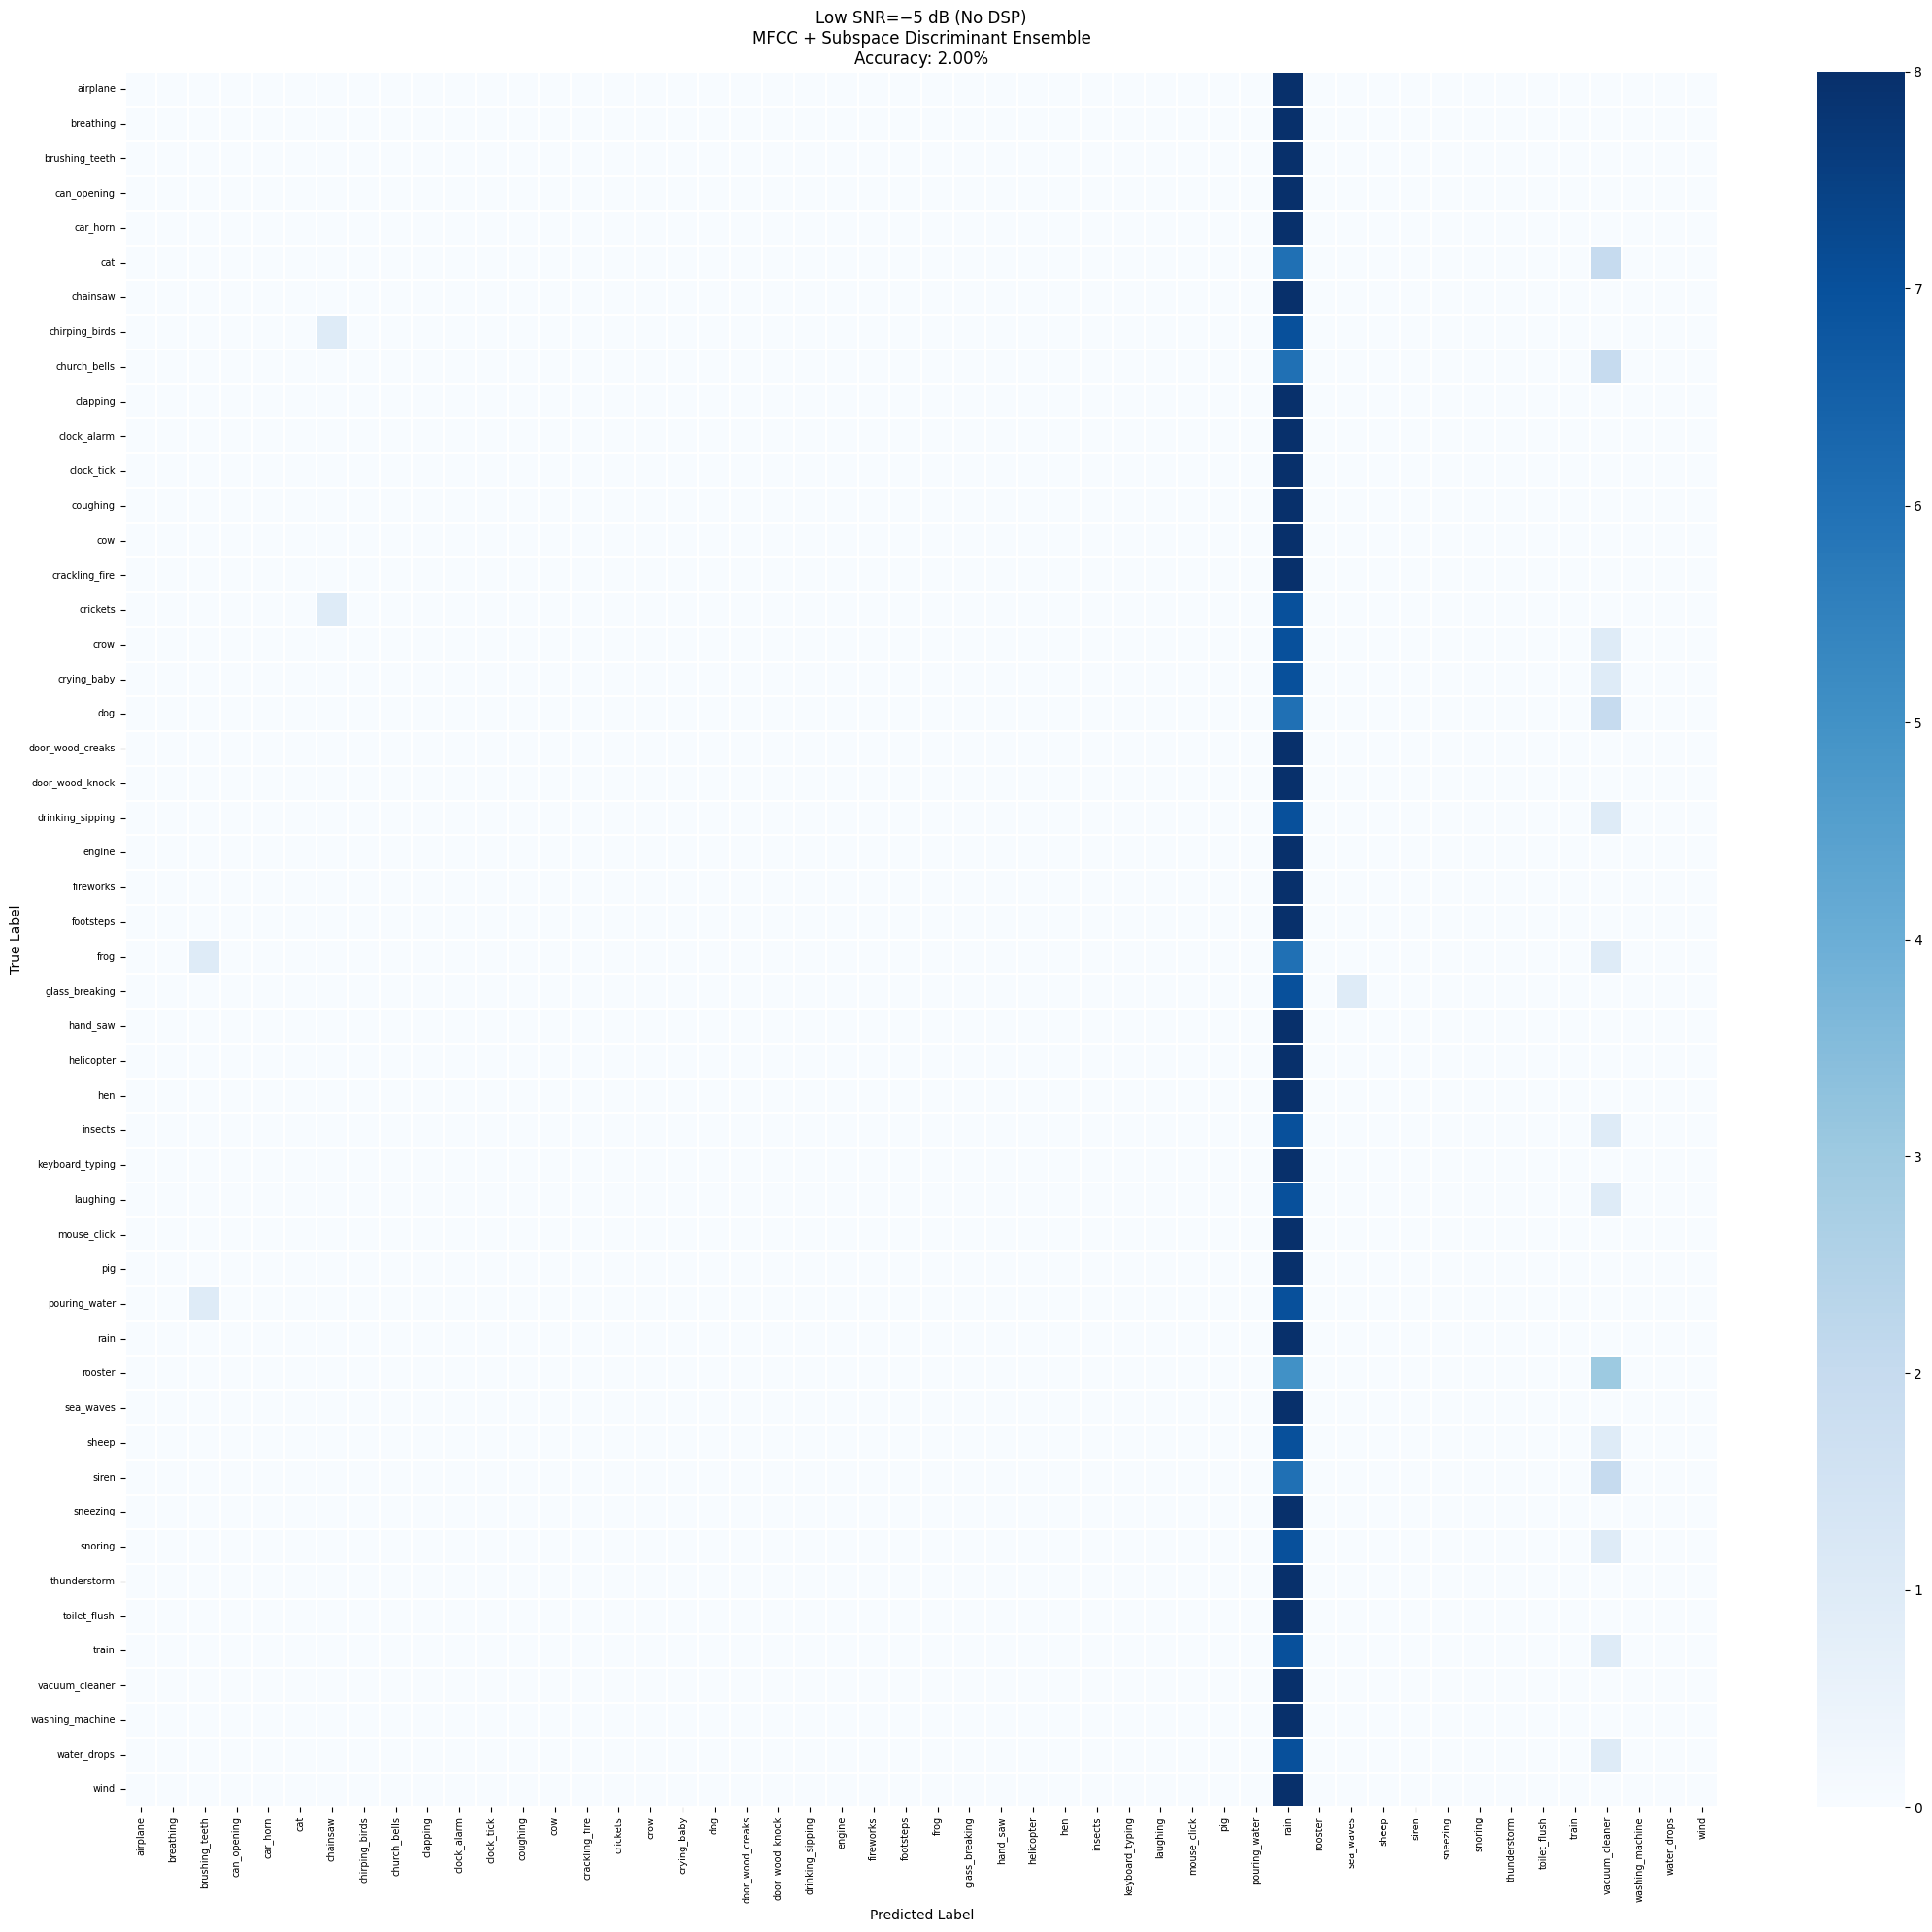

Saved → /content/drive/MyDrive/DSP Project/mfcc_noise_results/cm_lowsnr_minus5db_noisy.png

Low SNR=−5 dB + DSP …


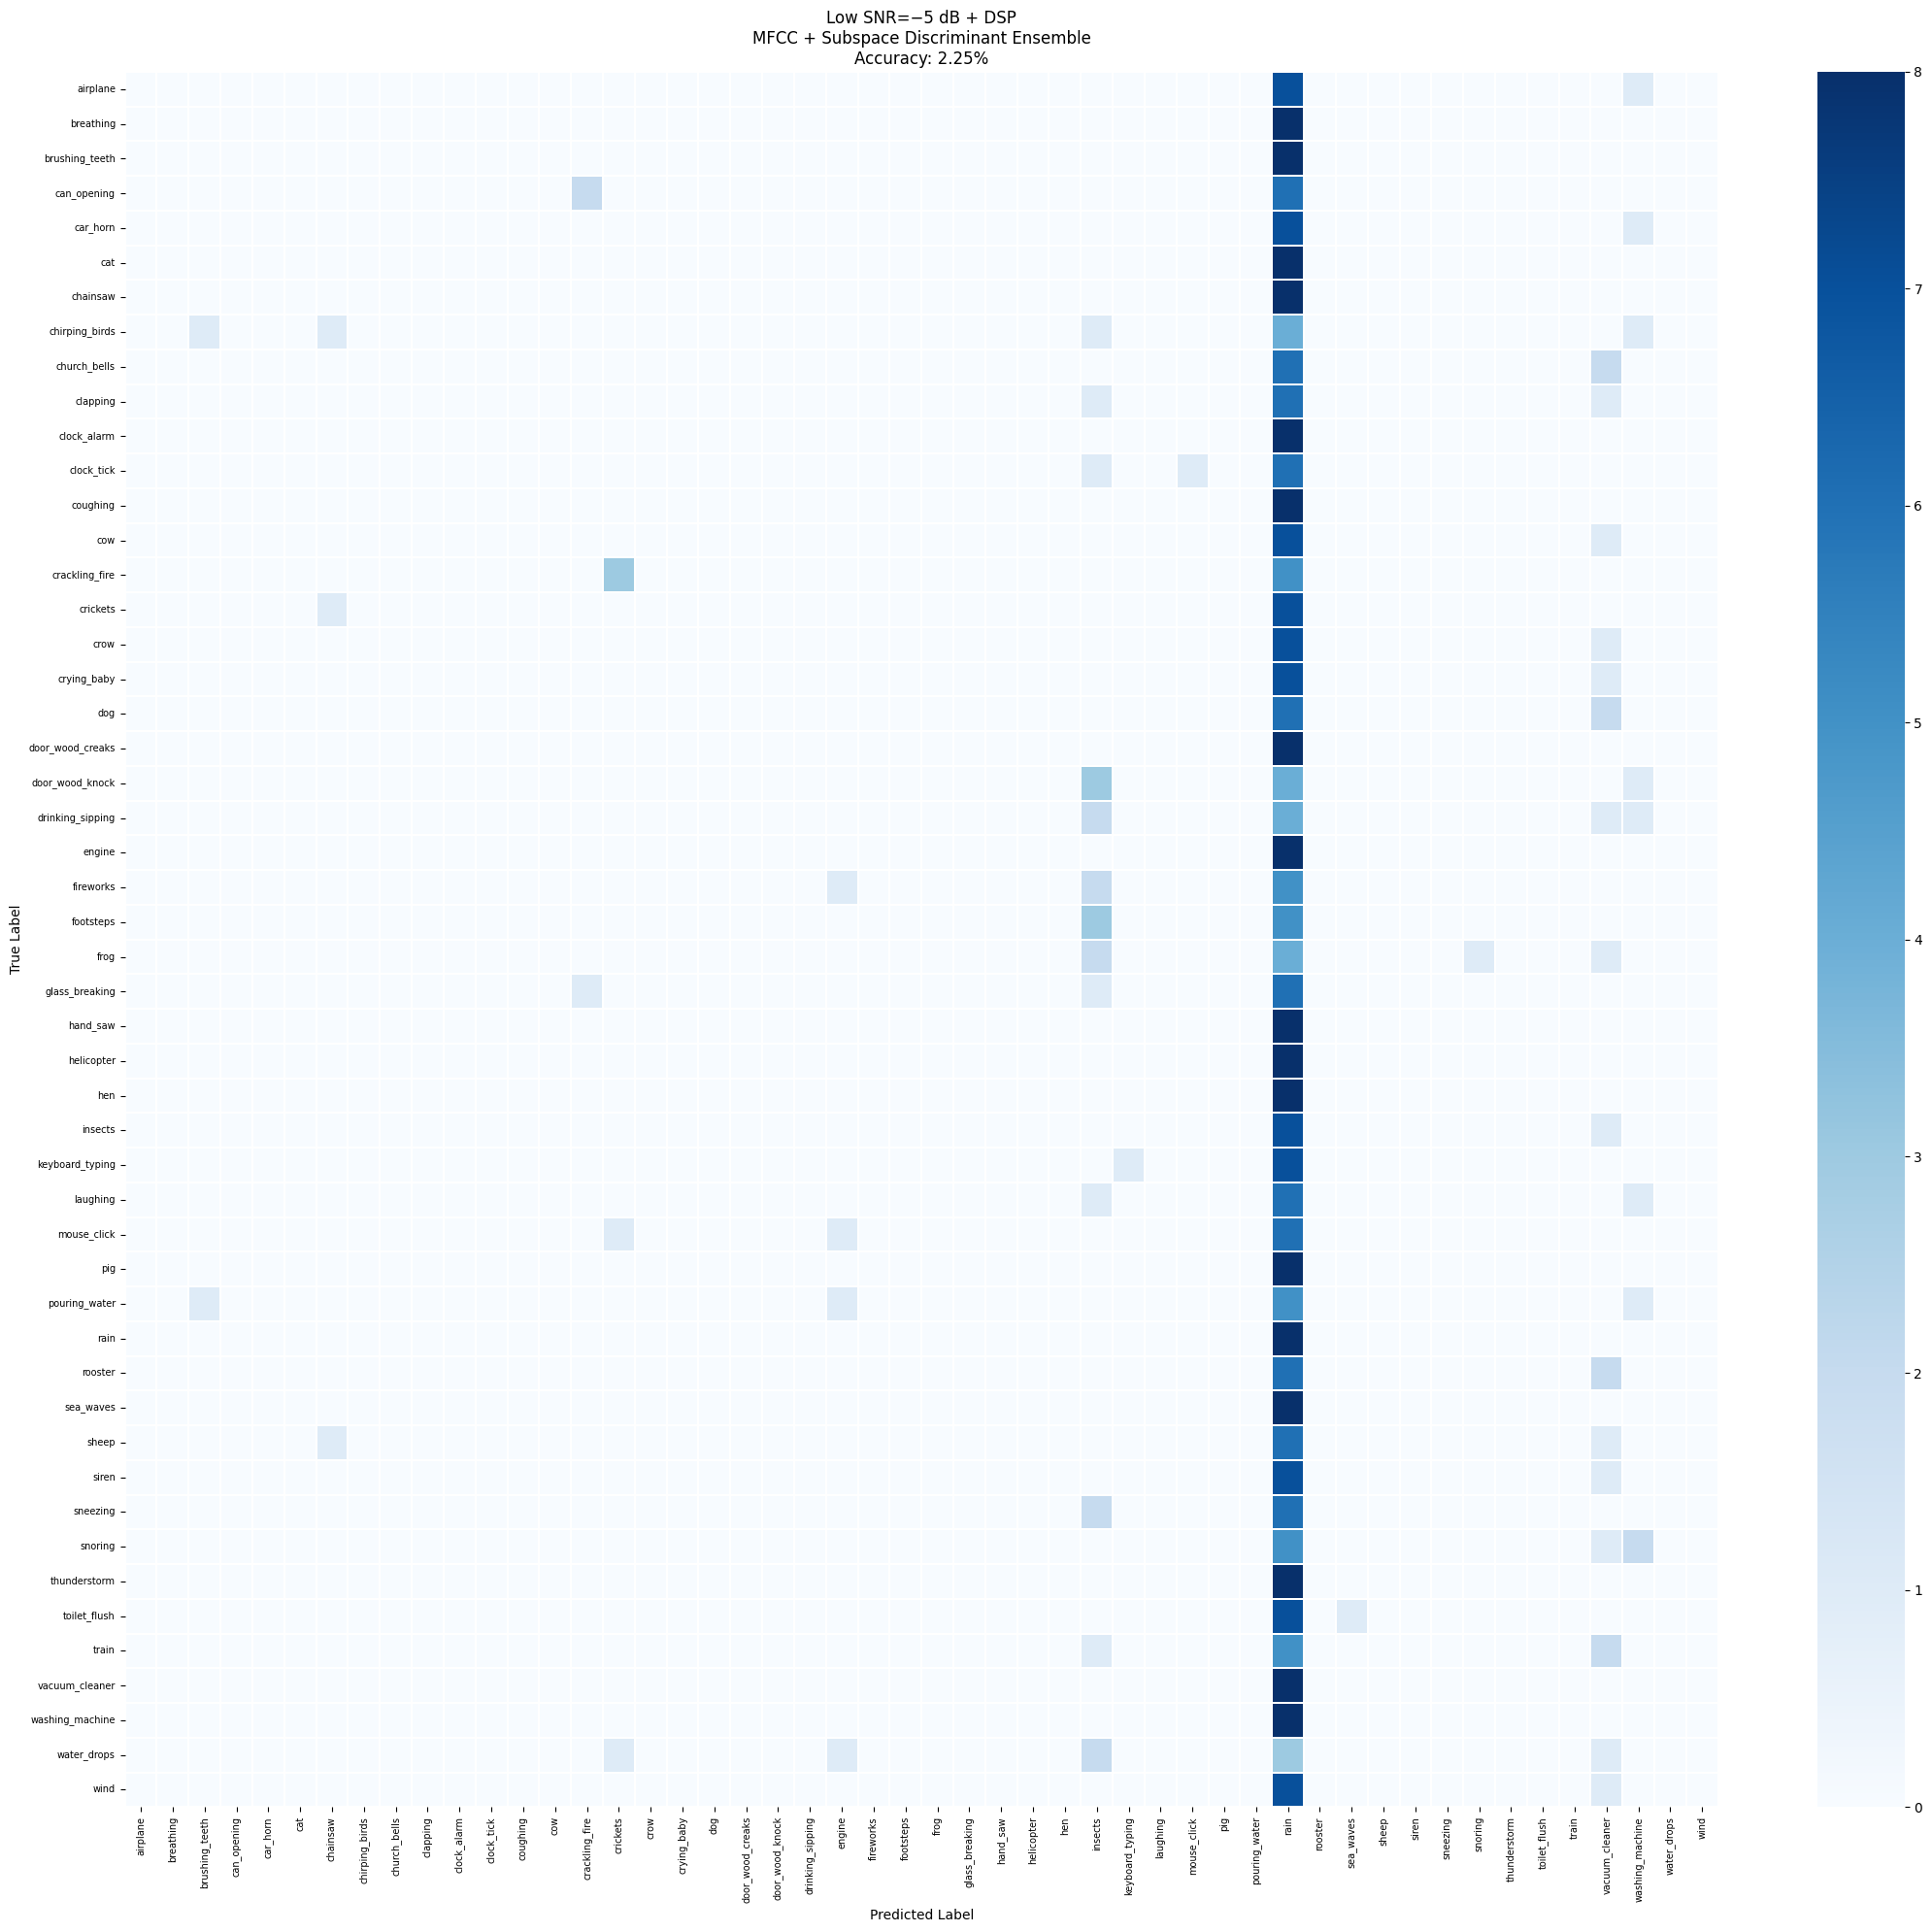

Saved → /content/drive/MyDrive/DSP Project/mfcc_noise_results/cm_lowsnr_minus5db_dsp.png


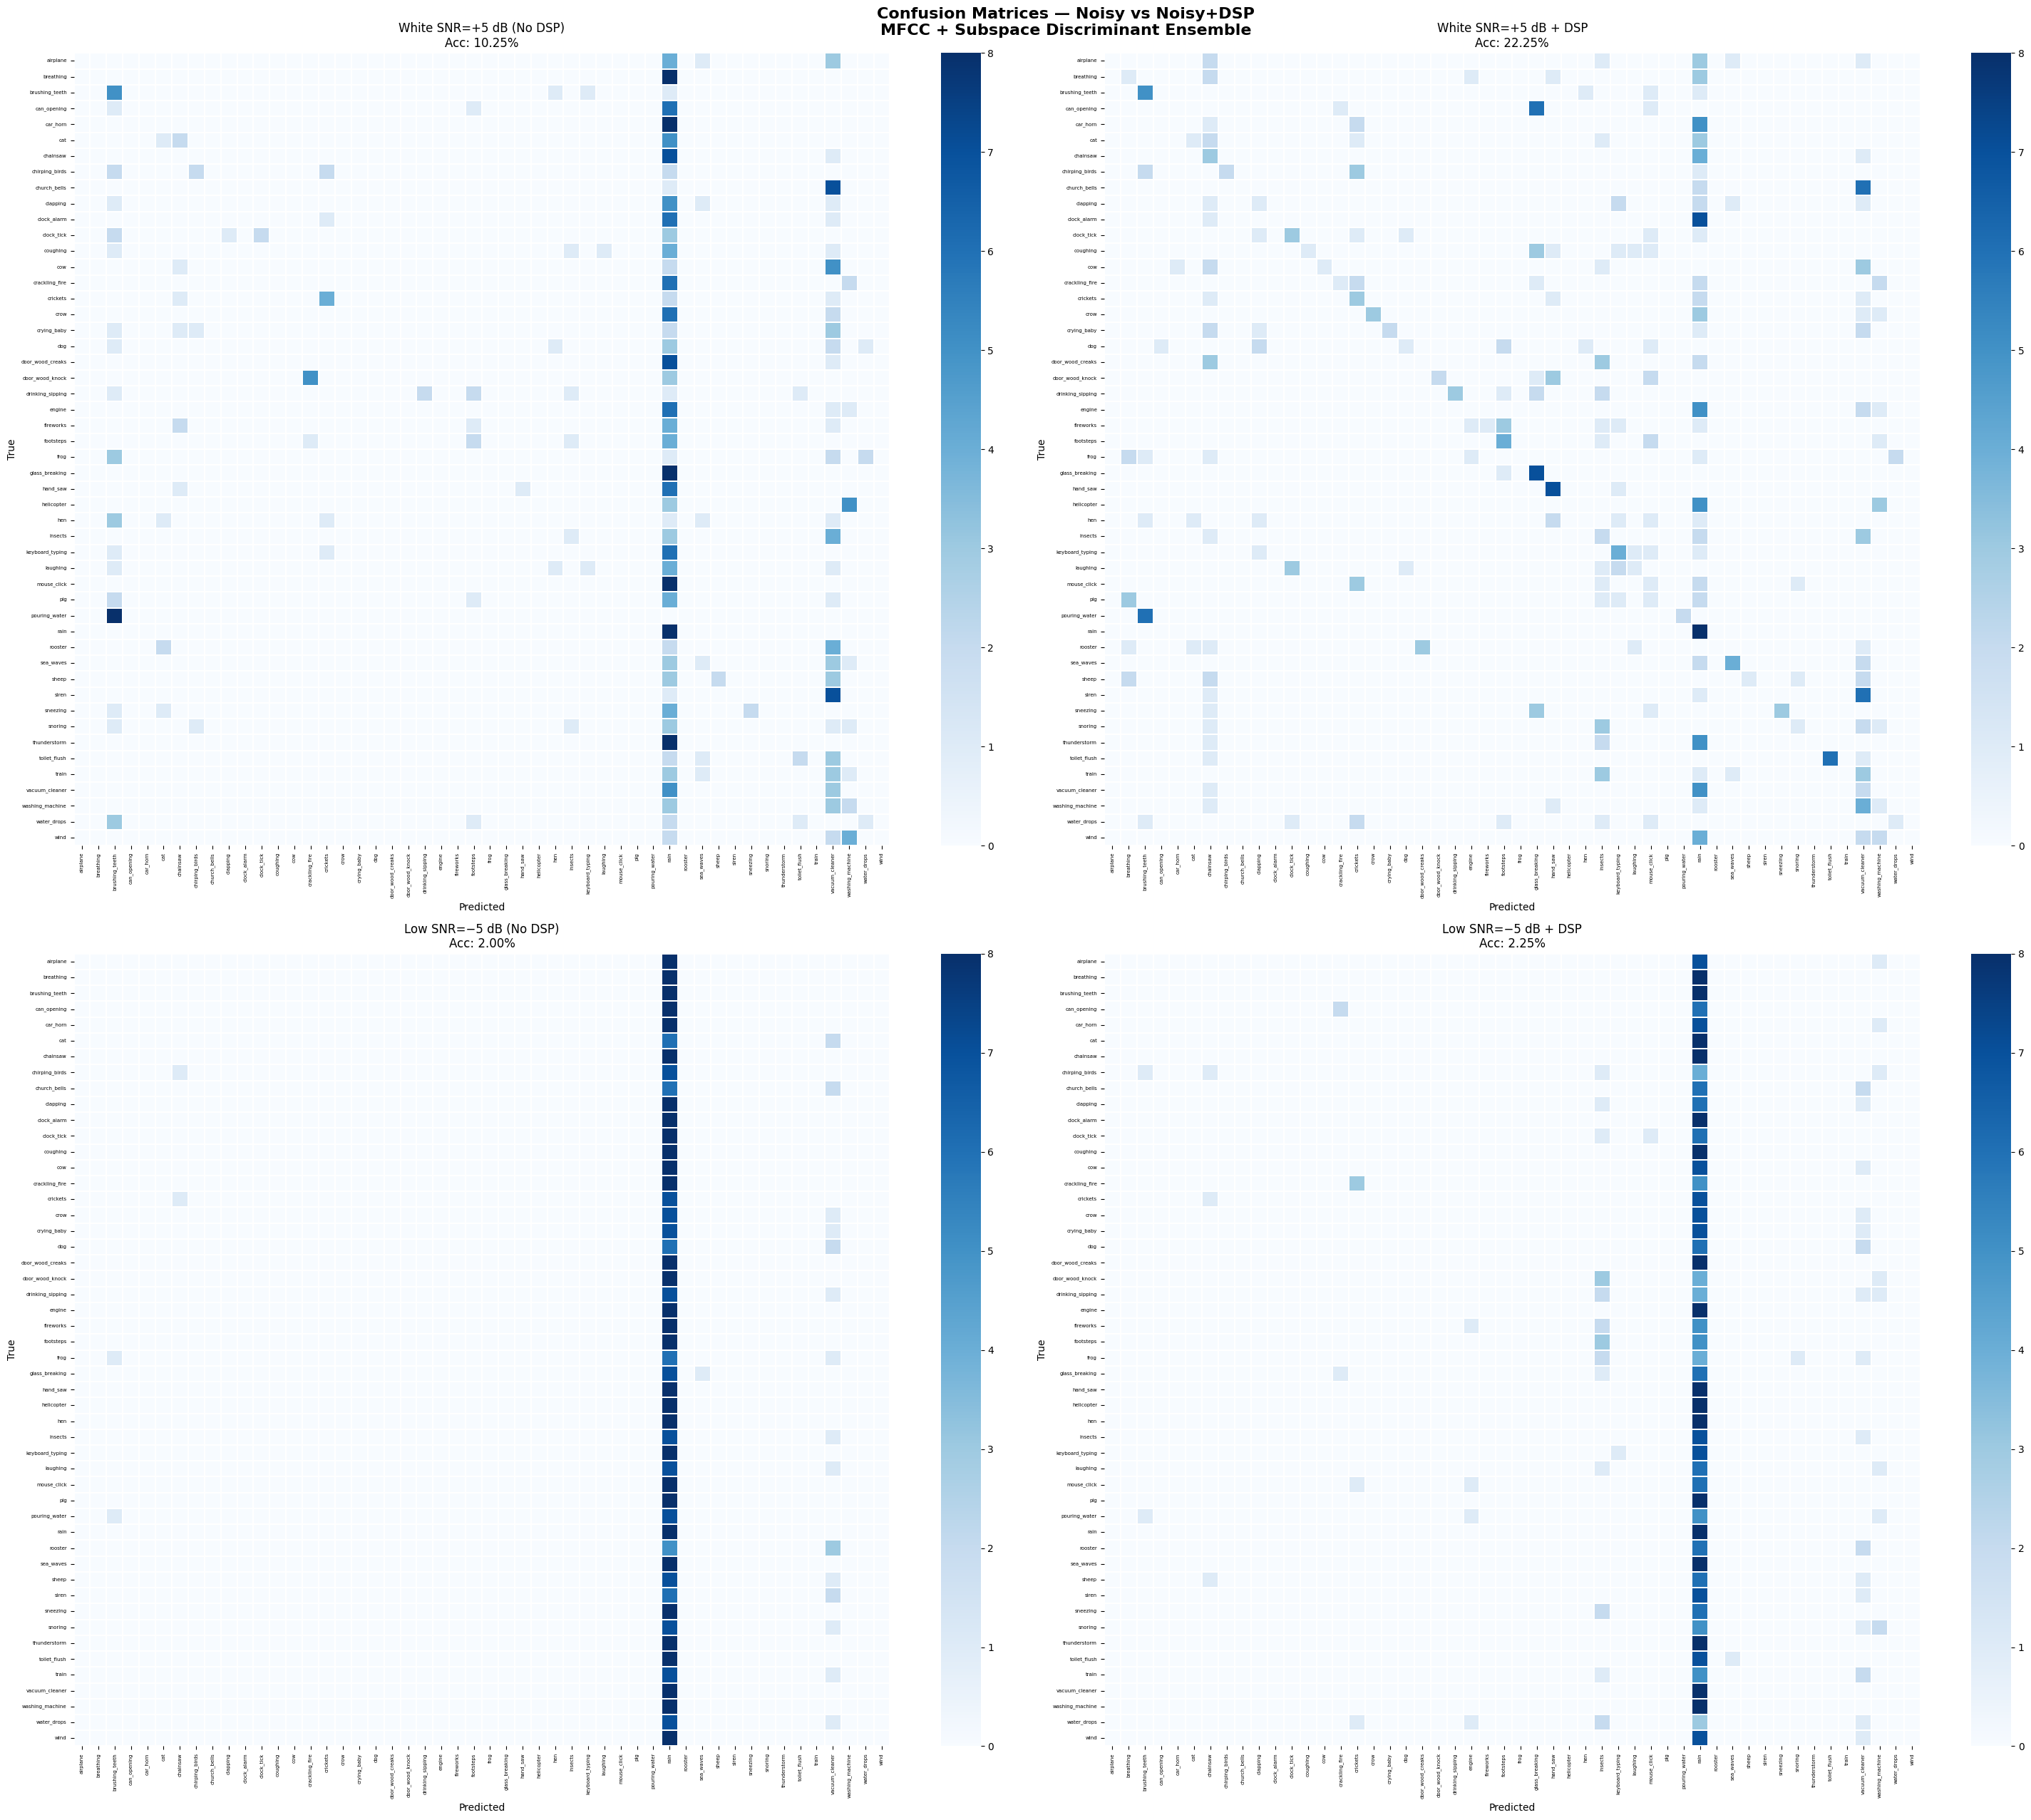


Combined figure saved → /content/drive/MyDrive/DSP Project/mfcc_noise_results/cm_comparison_5db_minus5db.png

  Confusion Matrix Accuracy Summary
  White  SNR=+5 dB  No DSP : 10.25%
  White  SNR=+5 dB  + DSP  : 22.25%
  Low    SNR=−5 dB  No DSP : 2.00%
  Low    SNR=−5 dB  + DSP  : 2.25%


In [54]:
# ============================================================
# CELL 23 — Confusion matrices: White SNR=+5 dB & Low SNR=−5 dB
# ============================================================

cm_configs = [
    (
        results["white"][5]["noisy_preds"],
        "White Noise SNR=+5 dB (No DSP)\nMFCC + Subspace Discriminant Ensemble",
        f"{RESULTS_DIR}/cm_white_5db_noisy.png",
    ),
    (
        results["white"][5]["dsp_preds"],
        "White Noise SNR=+5 dB + DSP\nMFCC + Subspace Discriminant Ensemble",
        f"{RESULTS_DIR}/cm_white_5db_dsp.png",
    ),
    (
        results["low_snr"][-5]["noisy_preds"],
        "Low SNR=−5 dB (No DSP)\nMFCC + Subspace Discriminant Ensemble",
        f"{RESULTS_DIR}/cm_lowsnr_minus5db_noisy.png",
    ),
    (
        results["low_snr"][-5]["dsp_preds"],
        "Low SNR=−5 dB + DSP\nMFCC + Subspace Discriminant Ensemble",
        f"{RESULTS_DIR}/cm_lowsnr_minus5db_dsp.png",
    ),
]

cms = []
for preds, title, path in cm_configs:
    print(f"\n{title.split(chr(10))[0]} …")
    cms.append(plot_confusion_matrix(preds, NOISE_LABELS, title, path))

cm_white5_noisy, cm_white5_dsp, cm_low5_noisy, cm_low5_dsp = cms

# ── 2×2 combined overview ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(30, 26))
fig.suptitle(
    'Confusion Matrices — Noisy vs Noisy+DSP\n'
    'MFCC + Subspace Discriminant Ensemble',
    fontsize=16, fontweight='bold',
)

overview = [
    (cm_white5_noisy, "White SNR=+5 dB (No DSP)",  axes[0, 0]),
    (cm_white5_dsp,   "White SNR=+5 dB + DSP",      axes[0, 1]),
    (cm_low5_noisy,   "Low SNR=−5 dB (No DSP)",     axes[1, 0]),
    (cm_low5_dsp,     "Low SNR=−5 dB + DSP",         axes[1, 1]),
]

for cm, title, ax in overview:
    acc = np.trace(cm) / np.sum(cm) * 100
    sns.heatmap(
        cm, annot=False, cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.2, ax=ax,
    )
    ax.set(
        title=f'{title}\nAcc: {acc:.2f}%',
        xlabel='Predicted', ylabel='True',
    )
    ax.tick_params(axis='x', rotation=90, labelsize=5)
    ax.tick_params(axis='y', rotation=0,  labelsize=5)

plt.tight_layout()
combined_path = f"{RESULTS_DIR}/cm_comparison_5db_minus5db.png"
plt.savefig(combined_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nCombined figure saved → {combined_path}")

# ── Summary ───────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  Confusion Matrix Accuracy Summary")
print("=" * 55)
for cm, label in zip(cms, [
    "White  SNR=+5 dB  No DSP",
    "White  SNR=+5 dB  + DSP ",
    "Low    SNR=−5 dB  No DSP",
    "Low    SNR=−5 dB  + DSP ",
]):
    print(f"  {label} : {np.trace(cm) / np.sum(cm) * 100:.2f}%")
print("=" * 55)

In [ ]:
# ============================================================
# CELL 24 — Confusion matrices: Gaussian SNR=+15 dB
# ============================================================

print("Plotting Gaussian SNR=+15 dB …")
cm_gauss15_noisy = plot_confusion_matrix(
    preds     = results["gaussian"][15]["noisy_preds"],
    labels    = NOISE_LABELS,
    title     = "Gaussian Noise SNR=+15 dB (No DSP)\nMFCC + Subspace Discriminant Ensemble",
    save_path = f"{RESULTS_DIR}/cm_gaussian_15db_noisy.png",
)
cm_gauss15_dsp = plot_confusion_matrix(
    preds     = results["gaussian"][15]["dsp_preds"],
    labels    = NOISE_LABELS,
    title     = "Gaussian Noise SNR=+15 dB + DSP\nMFCC + Subspace Discriminant Ensemble",
    save_path = f"{RESULTS_DIR}/cm_gaussian_15db_dsp.png",
)

# ── Side-by-side comparison ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(30, 14))
fig.suptitle(
    'Gaussian Noise SNR=+15 dB — No DSP vs With DSP\n'
    'MFCC + Subspace Discriminant Ensemble',
    fontsize=16, fontweight='bold',
)
for cm, title, ax in [
    (cm_gauss15_noisy, "Gaussian SNR=+15 dB (No DSP)", axes[0]),
    (cm_gauss15_dsp,   "Gaussian SNR=+15 dB + DSP",    axes[1]),
]:
    acc = np.trace(cm) / np.sum(cm) * 100
    sns.heatmap(
        cm, annot=False, cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.2, ax=ax,
    )
    ax.set(title=f'{title}\nAcc: {acc:.2f}%',
           xlabel='Predicted', ylabel='True')
    ax.tick_params(axis='x', rotation=90, labelsize=5)
    ax.tick_params(axis='y', rotation=0,  labelsize=5)

plt.tight_layout()
gauss_cmp = f"{RESULTS_DIR}/cm_gaussian_15db_comparison.png"
plt.savefig(gauss_cmp, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved → {gauss_cmp}")

noisy_acc = np.trace(cm_gauss15_noisy) / np.sum(cm_gauss15_noisy) * 100
dsp_acc   = np.trace(cm_gauss15_dsp)   / np.sum(cm_gauss15_dsp)   * 100
print(f"  Gaussian +15 dB  No DSP : {noisy_acc:.2f}%")
print(f"  Gaussian +15 dB  + DSP  : {dsp_acc:.2f}%")
print(f"  DSP gain                : {dsp_acc - noisy_acc:+.2f} pp")

---
## 16. Evaluation Metrics & ROC Curves

In [ ]:
# ============================================================
# CELL 25 — Precision, Recall, F1, and macro-average ROC
# ============================================================

print("=" * 55)
print("  MODEL EVALUATION METRICS — KEY CONDITIONS")
print("=" * 55)

# ── Conditions to evaluate ────────────────────────────────────
EVAL_CONDITIONS = {
    "Clean Baseline"        : (model.predict(X_test_scaled),          y_test),
    "White  SNR=+15 dB"     : (results["white"][15]["noisy_preds"],    test_labels_audio),
    "White  SNR= +0 dB"     : (results["white"][0]["noisy_preds"],     test_labels_audio),
    "White  +DSP SNR=+15 dB": (results["white"][15]["dsp_preds"],      test_labels_audio),
    "Gauss  SNR=+15 dB"     : (results["gaussian"][15]["noisy_preds"], test_labels_audio),
    "Gauss  +DSP SNR=+15 dB": (results["gaussian"][15]["dsp_preds"],   test_labels_audio),
    "LowSNR SNR= +5 dB"     : (results["low_snr"][5]["noisy_preds"],   test_labels_audio),
    "LowSNR +DSP SNR= +5 dB": (results["low_snr"][5]["dsp_preds"],     test_labels_audio),
}

# ── Metrics table ─────────────────────────────────────────────
hdr = f"  {'Condition':<28} {'Accuracy':>8} {'Precision':>10} {'Recall':>8} {'F1':>8}"
print(f"\n{hdr}")
print(f"  {'-'*28} {'-'*8} {'-'*10} {'-'*8} {'-'*8}")

for cond_name, (preds, labels) in EVAL_CONDITIONS.items():
    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='macro', zero_division=0)
    rec  = recall_score(labels,   preds, average='macro', zero_division=0)
    f1   = f1_score(labels,       preds, average='macro', zero_division=0)
    print(
        f"  {cond_name:<28}"
        f"  {acc*100:>7.2f}%"
        f"  {prec*100:>9.2f}%"
        f"  {rec*100:>7.2f}%"
        f"  {f1*100:>7.2f}%"
    )

In [ ]:
# ============================================================
# CELL 26 — Macro-average ROC curves
# ============================================================
# Binarises the 50-class problem using One-vs-Rest and
# interpolates individual class ROC curves onto a shared
# FPR grid to compute the macro-average.
# ============================================================

print("⏳ Computing ROC curves …")

CLASSES_SORTED = sorted(np.unique(y_test))
y_test_bin     = label_binarize(y_test,            classes=CLASSES_SORTED)
y_audio_bin    = label_binarize(test_labels_audio, classes=CLASSES_SORTED)


def macro_roc(X_scaled: np.ndarray,
              y_bin:    np.ndarray) -> tuple:
    """Compute macro-average ROC (FPR, TPR, AUC) from scaled features."""
    y_prob = model.predict_proba(X_scaled)

    # Union of all class FPR values for interpolation grid
    all_fpr = np.unique(np.concatenate([
        roc_curve(y_bin[:, i], y_prob[:, i])[0]
        for i in range(len(CLASSES_SORTED))
    ]))

    # Interpolate each class TPR onto the shared grid, then average
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(CLASSES_SORTED)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        mean_tpr   += np.interp(all_fpr, fpr, tpr)
    mean_tpr /= len(CLASSES_SORTED)

    return all_fpr, mean_tpr, auc(all_fpr, mean_tpr)


def waves_to_scaled_features(waves: np.ndarray) -> np.ndarray:
    """Extract MFCC features from waveforms and apply the fitted scaler."""
    feats = np.array(
        [extract_features_from_wave(w) for w in waves],
        dtype=np.float32,
    )
    return scaler.transform(feats)


# ── ROC configuration ─────────────────────────────────────────
roc_configs = [
    ("Clean Baseline",
     X_test_scaled,
     y_test_bin,
     '#2ecc71', '-',  2.5),
    ("White SNR=+15 dB",
     waves_to_scaled_features(results["white"][15]["noisy_waves"]),
     y_audio_bin,
     '#e74c3c', '--', 1.8),
    ("White SNR= +0 dB",
     waves_to_scaled_features(results["white"][0]["noisy_waves"]),
     y_audio_bin,
     '#c0392b', ':',  1.8),
    ("White +DSP SNR=+15 dB",
     waves_to_scaled_features(results["white"][15]["clean_waves"]),
     y_audio_bin,
     '#3498db', '--', 1.8),
]

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for label, X_sc, y_bin, color, ls, lw in roc_configs:
    fpr, tpr, macro_auc = macro_roc(X_sc, y_bin)
    ax.plot(fpr, tpr, color=color, lw=lw, linestyle=ls,
            label=f'{label}  (AUC = {macro_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
ax.set(
    xlabel='False Positive Rate', ylabel='True Positive Rate',
    title='Macro-Average ROC Curve\nClean vs Noisy vs Noisy+DSP',
    xlim=[0, 1], ylim=[0, 1.02],
)
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
roc_path = f"{RESULTS_DIR}/mfcc_roc_curve.png"
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {roc_path}")

In [ ]:
# ============================================================
# CELL 27 — Confusion matrices for four key conditions
# ============================================================

KEY_CM_CONDITIONS = {
    "Clean Baseline"       : (model.predict(X_test_scaled),       y_test),
    "White SNR=+15 dB"     : (results["white"][15]["noisy_preds"], test_labels_audio),
    "White SNR= +0 dB"     : (results["white"][0]["noisy_preds"],  test_labels_audio),
    "White +DSP SNR=+15 dB": (results["white"][15]["dsp_preds"],   test_labels_audio),
}

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle(
    'Confusion Matrices — Key Conditions\n'
    'MFCC + Subspace Discriminant Ensemble',
    fontsize=14, fontweight='bold',
)

for ax, (cond_name, (preds, labels)) in zip(
    axes.flatten(), KEY_CM_CONDITIONS.items()
):
    cm  = confusion_matrix(labels, preds, labels=CLASSES_SORTED)
    acc = np.trace(cm) / np.sum(cm) * 100
    im  = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set(
        title=f'{cond_name}\nAccuracy: {acc:.2f}%',
        xlabel='Predicted Label', ylabel='True Label',
        xticks=np.arange(len(CLASSES_SORTED)),
        yticks=np.arange(len(CLASSES_SORTED)),
    )
    ax.set_xticklabels(CLASSES_SORTED, rotation=90, fontsize=5)
    ax.set_yticklabels(CLASSES_SORTED, fontsize=5)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
cm_path = f"{RESULTS_DIR}/mfcc_confusion_matrices.png"
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {cm_path}")

---
## 17. Final Summary

In [ ]:
# ============================================================
# CELL 28 — Complete experiment summary
# ============================================================

DIVIDER = "=" * 65

print(f"\n{DIVIDER}")
print("  COMPLETE EXPERIMENT SUMMARY")
print("  MFCC + Subspace Discriminant Ensemble (ESC-50)")
print(DIVIDER)

# ── Condition 1 ───────────────────────────────────────────────
print(f"\n  CONDITION 1 — Clean Baseline")
print(f"     Accuracy : {clean_acc * 100:.2f}%  (MATLAB target: 53.0%)")

# ── Conditions 2 & 3 ──────────────────────────────────────────
noise_display_map = [
    ("White",    "white"),
    ("Gaussian", "gaussian"),
    ("Low SNR",  "low_snr"),
]

print(f"\n  CONDITION 2 — Noisy (no DSP)")
for noise_label, noise_key in noise_display_map:
    snr_levels = SNR_MAP[noise_key][0]
    print(f"\n     {noise_label} Noise:")
    for snr in snr_levels:
        acc  = results[noise_key][snr]["noisy_acc"] * 100
        drop = clean_acc * 100 - acc
        print(f"       SNR={snr:+3d} dB → {acc:.2f}%  (drop: {drop:.2f} pp)")

print(f"\n  CONDITION 3 — Noisy + MMSE-LSA DSP")
for noise_label, noise_key in noise_display_map:
    snr_levels = SNR_MAP[noise_key][0]
    print(f"\n     {noise_label} Noise + DSP:")
    for snr in snr_levels:
        noisy = results[noise_key][snr]["noisy_acc"] * 100
        dsp   = results[noise_key][snr]["dsp_acc"]   * 100
        print(f"       SNR={snr:+3d} dB → {dsp:.2f}%  "
              f"(DSP Δ: {dsp - noisy:+.2f} pp)")

print(f"\n{DIVIDER}")
print(f"  OUTPUT FILES ({RESULTS_DIR}/)")
print(DIVIDER)
output_files = [
    "mfcc_noise_results.csv",
    "mfcc_accuracy_vs_snr.png",
    "mfcc_grouped_bar.png",
    "mfcc_dsp_heatmap.png",
    "mfcc_roc_curve.png",
    "mfcc_confusion_matrices.png",
    "dsp_analysis.png",
    "cm_white_5db_noisy.png",
    "cm_white_5db_dsp.png",
    "cm_lowsnr_minus5db_noisy.png",
    "cm_lowsnr_minus5db_dsp.png",
    "cm_comparison_5db_minus5db.png",
    "cm_gaussian_15db_noisy.png",
    "cm_gaussian_15db_dsp.png",
    "cm_gaussian_15db_comparison.png",
]
for fname in output_files:
    print(f"  • {fname}")
print(f"{DIVIDER}")